# Primena Neuronskih Mreza za Predvidjanje Prevara u Finansijama
## Credit Card Fraud Detection -- Duboko Ucenje i Neuronske Mreze

**Predmet:** Duboko ucenje i neuronske mreze
**Student:** [Ime i prezime, broj indeksa]
**Dataset:** [Kaggle -- Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

---

### Zadatak i cilj

U ovom radu sam se bavila detekcijom prevara u finansijskim transakcijama pomocu
neuronskih mreza. Glavni izazov ovog dataseta je sto je izrazito nebalansiran -- svega
0.17% transakcija su prevare -- pa je vecina rada zapravo posvecena tome kako se ta
nebalansiranost tretira, a ne samo izboru arhitekture mreze.

Kroz notebook prolazim kroz nekoliko pristupa i pokusavam da objasnim zasto svaki sledeci
korak ima smisla:

- zasto obicna accuracy ovde ne govori nista korisno,
- kako class weighting menja ponasanje modela,
- kako podesavanje praga odlucivanja (threshold tuning) utice na precision/recall,
- SMOTE kao alternativni nacin balansiranja podataka,
- i na kraju, autoencoder kao potpuno drugaciji, unsupervised pristup istom problemu.

### O datasetu

| Karakteristika | Vrednost |
|---|---|
| Ukupno transakcija | 284,807 |
| Fraudulentnih | 492 (0.172%) |
| Legitimnih | 284,315 (99.827%) |
| Karakteristike | V1-V28 (PCA), Time, Amount |
| Ciljna varijabla | Class (0=legitimno, 1=prevara) |

Napomena: originalne karakteristike (V1-V28) su vec PCA transformisane od strane autora
dataseta radi zastite privatnosti korisnika, tako da ne znamo sta tacno predstavljaju --
radimo sa njima kao sa "crnom kutijom".

In [9]:
# ============================================================
# 1. UVOZ BIBLIOTEKA
# ============================================================

import numpy as np
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, f1_score,
    precision_score, recall_score, roc_curve
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

# Seed za reproduktibilnost - garantuje iste rezultate pri svakom pokretanju
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Globalni stil grafika - tamna, profesionalna tema
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor':   '#16213e',
    'axes.edgecolor':   '#0f3460',
    'text.color':       'white',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'grid.color':       '#0f3460',
    'grid.alpha':       0.5,
    'font.size':        11,
})

# Paleta boja
FRAUD_COLOR     = '#e74c3c'   # Crvena - prevare
LEGIT_COLOR     = '#2ecc71'   # Zelena - legitimne
PRIMARY_COLOR   = '#3498db'   # Plava
SECONDARY_COLOR = '#9b59b6'   # Ljubicasta

print(f'TensorFlow: {tf.__version__}')
print(f'NumPy:      {np.__version__}')
print(f'Pandas:     {pd.__version__}')
print('Sve biblioteke su ucitane.')


TensorFlow: 2.21.0
NumPy:      2.5.1
Pandas:     3.0.3
Sve biblioteke su uspjesno uvezene!


## 2. Ucitavanje Podataka

Dataset je dostupan na Kaggle-u (besplatno, ~150 MB):

**Upute:**
1. Idi na: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
2. Preuzmi `creditcard.csv`
3. Postavi ga u isti folder kao ovaj notebook


In [10]:
# ============================================================
# 2. UCITAVANJE PODATAKA
# ============================================================

# Pretrazi dataset u standardnim lokacijama
df = None
for path in ['creditcard.csv', 'data/creditcard.csv', '../creditcard.csv']:
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f'Dataset ucitan iz: {path}')
        break

if df is None:
    raise FileNotFoundError(
        'creditcard.csv nije pronađen!\n'
        'Preuzmi sa: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud'
    )

print(f'Oblik dataseta: {df.shape}')
print(f'Nedostajuce vrednosti: {df.isnull().sum().sum()}')
df.head()


Dataset ucitan iz: creditcard.csv
Oblik dataseta: (284807, 31)
Nedostajuce vrijednosti: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [11]:
# Detaljne statistike dataseta
n_legit = (df['Class'] == 0).sum()
n_fraud = (df['Class'] == 1).sum()
imbalance_ratio = n_legit / n_fraud

print('=' * 60)
print('STATISTIKE DATASETA')
print('=' * 60)
print(f'Ukupno transakcija:      {len(df):>10,}')
print(f'Legitimnih (Class=0):    {n_legit:>10,}  ({n_legit/len(df)*100:.4f}%)')
print(f'Fraudulentnih (Class=1): {n_fraud:>10,}  ({n_fraud/len(df)*100:.4f}%)')
print(f'Imbalance ratio:         {imbalance_ratio:>10.0f} : 1')
print('=' * 60)

dummy_acc = n_legit / len(df) * 100
print(f'\nModel koji UVIJEK predvida legitimno => accuracy: {dummy_acc:.2f}%')
print('Ali bi nasao 0% prevara, sto znaci da accuracy ovde nije dobra metrika.')

df[['Time', 'Amount', 'Class']].describe().round(3)


STATISTIKE DATASETA
Ukupno transakcija:         284,807
Legitimnih (Class=0):       284,315  (99.8273%)
Fraudulentnih (Class=1):        492  (0.1727%)
Imbalance ratio:                578 : 1

Model koji UVIJEK predvida legitimno => accuracy: 99.83%
Ali bi nasao 0% prevara => accuracy NIJE dobra metrika!


,Time,Amount,Class
count,284807.000,284807.000,284807.000
mean,94813.860,88.350,0.002
std,47488.146,250.120,0.042
min,0.000,0.000,0.000
25%,54201.500,5.600,0.000
50%,84692.000,22.000,0.000
75%,139320.500,77.165,0.000
max,172792.000,25691.160,1.000


## 3. Eksploratorna Analiza Podataka (EDA)

EDA nam pomaze da razumemo strukturu podataka pre modeliranja:

1. **Distribucija klasa** -- vizualizacija class imbalance problema
2. **Analiza Amount i Time** -- razlike izmedju legitimnih i fraud transakcija
3. **Korelaciona matrica** -- odnosi izmedju karakteristika i target varijable

> **Kljucno pitanje:** Zasto nam je EDA vazna?
> Razumevanje podataka direktno utice na izbor modela i metoda tretmana nebalansiranosti.


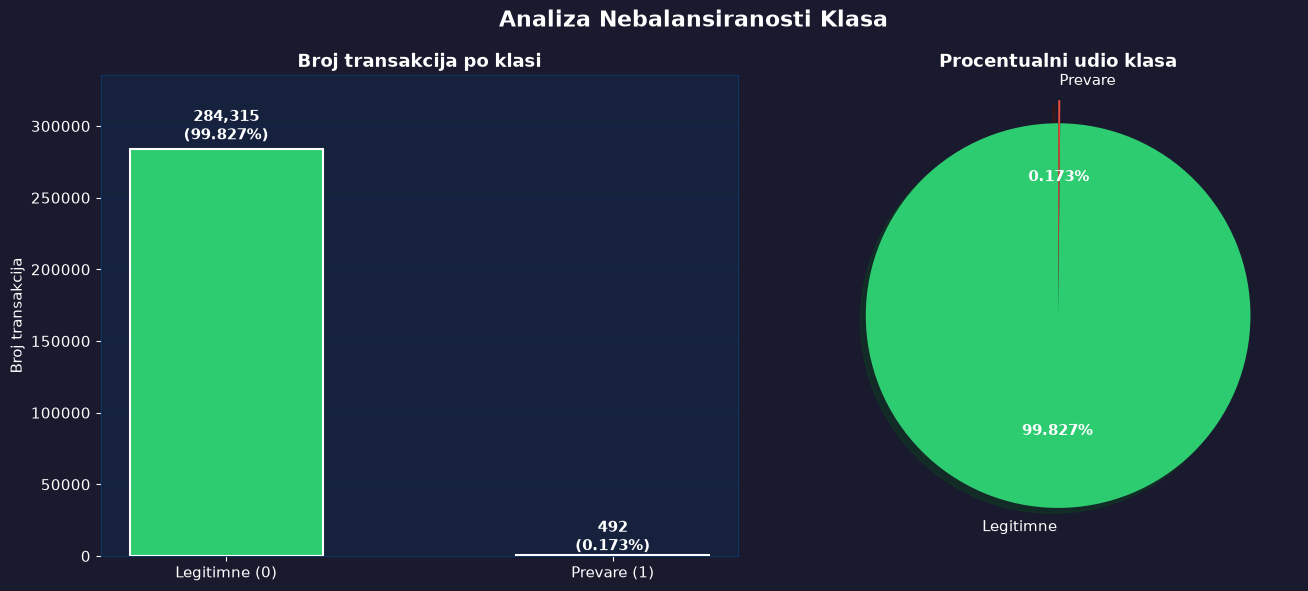

ANALIZA DISTRIBUCIJE KLASA:
  Imbalance ratio: 284,315 : 492 = 578:1

  Model koji uvijek predvida legitimno:
  - Accuracy:  99.83%  (zvuci odlicno!)
  - Recall:     0.00%  (ne detektuje NIJEDNU prevaru!)
  ZAKLJUCAK: Accuracy NIJE odgovarajuca metrika!
  Koristiti: Recall, Precision, F1-score, PR-AUC


In [12]:
# ============================================================
# EDA 1: DISTRIBUCIJA KLASA
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Analiza Nebalansiranosti Klasa', fontsize=16, fontweight='bold')

counts = df['Class'].value_counts().sort_index()

# Bar chart
bars = axes[0].bar(
    ['Legitimne (0)', 'Prevare (1)'],
    counts.values,
    color=[LEGIT_COLOR, FRAUD_COLOR],
    width=0.5, edgecolor='white', linewidth=1.5, zorder=3
)
axes[0].set_title('Broj transakcija po klasi', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Broj transakcija')
axes[0].set_ylim(0, counts.max() * 1.18)
axes[0].grid(axis='y', alpha=0.3, zorder=0)
for bar, n in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.01,
        f'{n:,}\n({n/len(df)*100:.3f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

# Pie chart
_, _, autotexts = axes[1].pie(
    counts.values,
    labels=['Legitimne', 'Prevare'],
    colors=[LEGIT_COLOR, FRAUD_COLOR],
    autopct='%1.3f%%', startangle=90, explode=(0, 0.12),
    shadow=True, textprops={'color': 'white', 'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Procentualni udeo klasa', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('ANALIZA DISTRIBUCIJE KLASA:')
print(f'  Imbalance ratio: {counts[0]:,} : {counts[1]:,} = {counts[0]/counts[1]:.0f}:1')
print()
print('  Model koji uvijek predvida legitimno:')
print(f'  - Accuracy:  {counts[0]/len(df)*100:.2f}%  (zvuci odlicno!)')
print(f'  - Recall:     0.00%  (ne detektuje NIJEDNU prevaru!)')
print('  Zakljucak: accuracy ovde nije odgovarajuca metrika.')
print('  Koristiti: Recall, Precision, F1-score, PR-AUC')


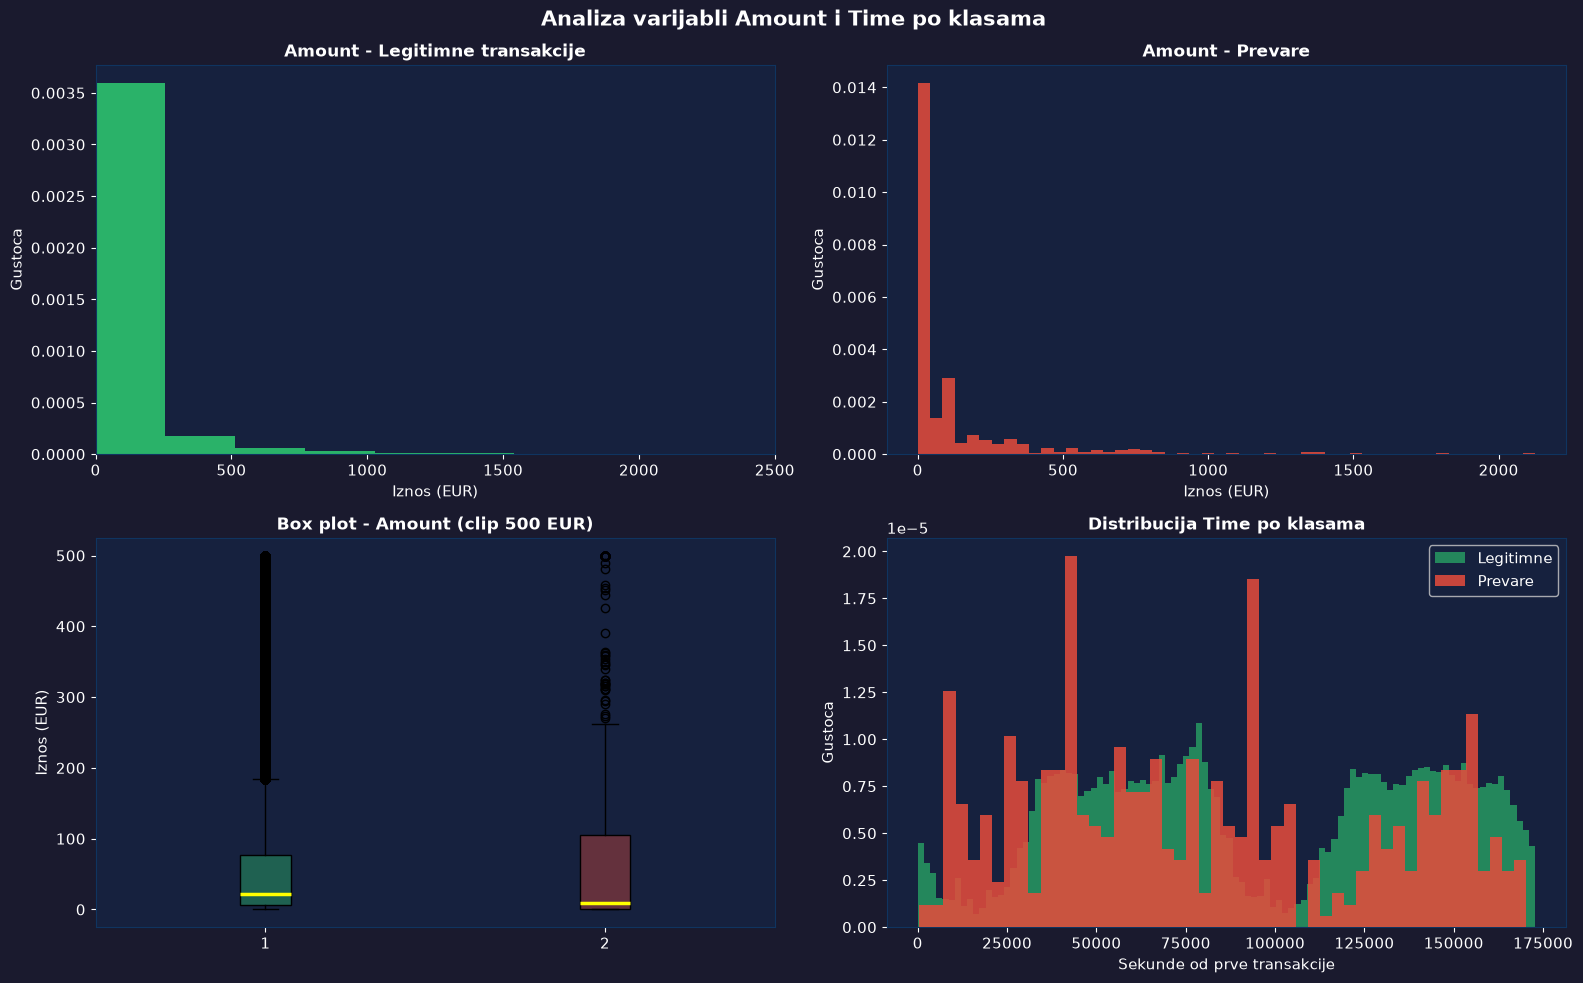

ANALIZA AMOUNT I TIME:
  Legitimne - prosjek: 88.29 EUR  | medijana: 22.00 EUR
  Prevare   - prosjek: 122.21 EUR  | medijana: 9.25 EUR

  -> Prevare imaju NIZI prosjek iznosa od legitimnih transakcija!
     Prevaranti cesto testiraju karticu malim iznosima.
  -> Time pokazuje 2 vala (dan/noc ritam), prevare su ravnomjernije rasporedene.


In [13]:
# ============================================================
# EDA 2: ANALIZA AMOUNT I TIME
# ============================================================
legit = df[df['Class'] == 0]
fraud = df[df['Class'] == 1]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Analiza varijabli Amount i Time po klasama', fontsize=15, fontweight='bold')

axes[0, 0].hist(legit['Amount'], bins=100, color=LEGIT_COLOR, alpha=0.85, edgecolor='none', density=True)
axes[0, 0].set_title('Amount - Legitimne transakcije', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Iznos (EUR)'); axes[0, 0].set_ylabel('Gustoca'); axes[0, 0].set_xlim(0, 2500)

axes[0, 1].hist(fraud['Amount'], bins=50, color=FRAUD_COLOR, alpha=0.85, edgecolor='none', density=True)
axes[0, 1].set_title('Amount - Prevare', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Iznos (EUR)'); axes[0, 1].set_ylabel('Gustoca')

bp = axes[1, 0].boxplot(
    [legit['Amount'].clip(upper=500), fraud['Amount'].clip(upper=500)],
    label=['Legitimne', 'Prevare'], patch_artist=True,
    medianprops=dict(color='yellow', linewidth=2.5)
)
bp['boxes'][0].set_facecolor(LEGIT_COLOR + '60')
bp['boxes'][1].set_facecolor(FRAUD_COLOR + '60')
axes[1, 0].set_title('Box plot - Amount (clip 500 EUR)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Iznos (EUR)')

axes[1, 1].hist(legit['Time'], bins=100, color=LEGIT_COLOR, alpha=0.6, label='Legitimne', density=True, zorder=2)
axes[1, 1].hist(fraud['Time'], bins=50, color=FRAUD_COLOR, alpha=0.85, label='Prevare', density=True, zorder=3)
axes[1, 1].set_title('Distribucija Time po klasama', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Sekunde od prve transakcije'); axes[1, 1].set_ylabel('Gustoca')
axes[1, 1].legend()

for ax in axes.flat:
    ax.set_facecolor('#16213e')
    for spine in ax.spines.values():
        spine.set_color('#0f3460')

plt.tight_layout()
plt.savefig('02_amount_time.png', dpi=150, bbox_inches='tight')
plt.show()

print('ANALIZA AMOUNT I TIME:')
print(f'  Legitimne - prosek: {legit["Amount"].mean():.2f} EUR  | medijana: {legit["Amount"].median():.2f} EUR')
print(f'  Prevare   - prosek: {fraud["Amount"].mean():.2f} EUR  | medijana: {fraud["Amount"].median():.2f} EUR')
print()
print('  -> Prevare imaju nizi prosek iznosa od legitimnih transakcija.')
print('     Prevaranti cesto testiraju karticu malim iznosima.')
print('  -> Time pokazuje 2 vala (dan/noc ritam), prevare su ravnomernije rasporedene.')


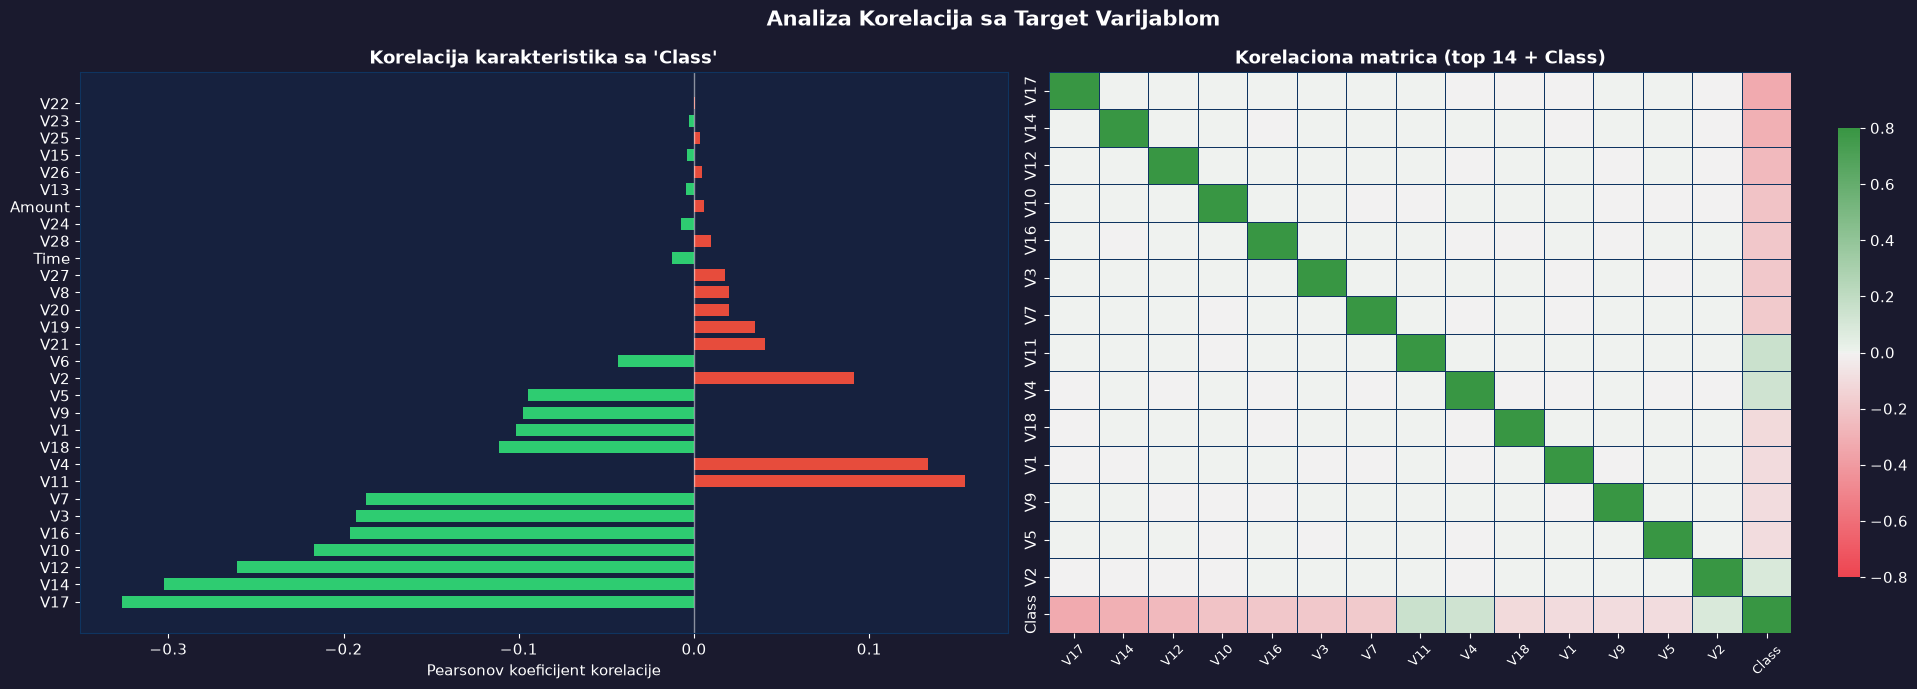

TOP 10 KARAKTERISTIKA NAJKORELIRANIJIH SA Class:
   1.  V17: -0.3265  (negativna korelacija)
   2.  V14: -0.3025  (negativna korelacija)
   3.  V12: -0.2606  (negativna korelacija)
   4.  V10: -0.2169  (negativna korelacija)
   5.  V16: -0.1965  (negativna korelacija)
   6.   V3: -0.1930  (negativna korelacija)
   7.   V7: -0.1873  (negativna korelacija)
   8.  V11: +0.1549  (pozitivna korelacija)
   9.   V4: +0.1334  (pozitivna korelacija)
  10.  V18: -0.1115  (negativna korelacija)


In [14]:
# ============================================================
# EDA 3: KORELACIONA MATRICA
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Analiza Korelacija sa Target Varijablom', fontsize=15, fontweight='bold')

class_corr = df.corr()['Class'].drop('Class').sort_values(key=abs, ascending=False)
bar_colors = [FRAUD_COLOR if v > 0 else LEGIT_COLOR for v in class_corr.values]
axes[0].barh(class_corr.index, class_corr.values, color=bar_colors, edgecolor='none', height=0.7)
axes[0].axvline(x=0, color='white', linewidth=1, alpha=0.5)
axes[0].set_title("Korelacija karakteristika sa 'Class'", fontsize=13, fontweight='bold')
axes[0].set_xlabel('Pearsonov koeficijent korelacije')
axes[0].set_facecolor('#16213e')

top_cols = list(class_corr.index[:14]) + ['Class']
corr_sub = df[top_cols].corr()
cmap = sns.diverging_palette(10, 130, s=80, l=55, n=256, as_cmap=True)
sns.heatmap(corr_sub, ax=axes[1], cmap=cmap, vmin=-0.8, vmax=0.8, center=0,
            linewidths=0.4, linecolor='#0f3460', annot=False, cbar_kws={'shrink': 0.8})
axes[1].set_title('Korelaciona matrica (top 14 + Class)', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=9)
axes[1].set_facecolor('#16213e')

plt.tight_layout()
plt.savefig('03_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('TOP 10 KARAKTERISTIKA NAJKORELIRANIJIH SA Class:')
for i, (feat, val) in enumerate(class_corr.head(10).items(), 1):
    direction = 'pozitivna' if val > 0 else 'negativna'
    print(f'  {i:2}. {feat:>4}: {val:+.4f}  ({direction} korelacija)')


## 4. Preprocessing

### Koraci predprocesiranja

1. **Skaliranje `Amount` i `Time`** (StandardScaler: mean=0, std=1)  
   Karakteristike V1-V28 su vec standardizovane PCA transformacijom.
   Neuronske mreze su osetljive na razlicite skale ulaznih podataka!

2. **Stratifikovana podela 70% / 15% / 15%** (train/val/test)  

### Zasto stratifikovana podela?

Kod izrazito nebalansiranih dataseta, nasumicna podela moze dovesti do toga da test skup
ima premalo fraud primera. **Stratifikacija garantuje isti udeo fraud transakcija** (~0.172%)
u svakom skupu -- kljucno za pouzdanu evaluaciju.


In [15]:
# ============================================================
# 4. PREPROCESSING
# ============================================================

# 4.1 Priprema X i y (split PRIJE skaliranja -- sprecava data leakage!)
# Uklanjamo Amount i Time -- skaliracemo ih tek nakon train/val/test splita.
X_raw = df.drop('Class', axis=1).values
y     = df['Class'].values

# 4.2 Stratifikovana podela 70% / 15% / 15%
# Radimo split na sirovim podacima -- scaler jos uvijek NIJE fittovan.
X_temp, X_test, y_temp, y_test = train_test_split(
    X_raw, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=SEED, stratify=y_temp
)

# 4.3 Skaliranje Amount i Time -- fit SAMO na train skupu!
# Ispravno: scaler uci mean/std samo od trening podataka.
# Pogresno bi bilo fit_transform(df) jer bi scaler video test i val podatke.
# Amount je zadnja kolona (indeks 29), Time je prva (indeks 0).
scaler_amount = StandardScaler()
scaler_time   = StandardScaler()

X_train[:, 29] = scaler_amount.fit_transform(X_train[:, [29]]).ravel()
X_train[:, 0]  = scaler_time.fit_transform(X_train[:, [0]]).ravel()

X_val[:, 29]   = scaler_amount.transform(X_val[:, [29]]).ravel()
X_val[:, 0]    = scaler_time.transform(X_val[:, [0]]).ravel()
X_test[:, 29]  = scaler_amount.transform(X_test[:, [29]]).ravel()
X_test[:, 0]   = scaler_time.transform(X_test[:, [0]]).ravel()

print('Skaliranje izvrseno (bez data leakage).')
print(f'  Scaler fittovan samo na train skupu ({len(X_train):,} primera)')
print(f'  Amount -- mean iz train: {scaler_amount.mean_[0]:.4f}  std: {scaler_amount.scale_[0]:.4f}')
print()
print('Stratifikovana podela podataka:')
print(f'  Train:      {len(X_train):>7,}  | Fraud: {y_train.sum():>3}  ({y_train.mean()*100:.3f}%)')
print(f'  Validation: {len(X_val):>7,}  | Fraud: {y_val.sum():>3}  ({y_val.mean()*100:.3f}%)')
print(f'  Test:       {len(X_test):>7,}  | Fraud: {y_test.sum():>3}  ({y_test.mean()*100:.3f}%)')

INPUT_DIM = X_train.shape[1]
print(f'\n  Input dimenzija: {INPUT_DIM}')


Skaliranje izvrseno (bez data leakage)!
  Scaler fittovan samo na train skupu (199,356 primjera)
  Amount -- mean iz train: 88.2361  std: 248.3858

Stratifikovana podjela podataka:
  Train:      199,356  | Fraud: 344  (0.173%)
  Validation:  42,729  | Fraud:  74  (0.173%)
  Test:        42,722  | Fraud:  74  (0.173%)

  Input dimenzija: 30


## 5. Evaluacione Metrike

### Zasto Accuracy NIJE dovoljna?

Model koji uvijek predvida 'legitimno' => **99.83% accuracy**, ali **0% Recall** za prevare.
Takav model je potpuno beskoristan u praksi.

### Koje metrike koristimo?

| Metrika | Formula | Sta meri |
|---|---|---|
| **Precision** | TP/(TP+FP) | Od predvidjenih prevara, koliko su zaista prevare? |
| **Recall** | TP/(TP+FN) | Od svih pravih prevara, koliko je model pronasao? |
| **F1-Score** | 2*P*R/(P+R) | Harmonijska sredina Precision i Recall |
| **PR-AUC** | Povrsina PR krive | Opsta sposobnost detekcije pri svim pragovima |
| **ROC-AUC** | Povrsina ROC krive | Diskriminativna sposobnost modela |

> **U detekciji prevara, Recall je kritican** -- propustena prevara (FN) je skuplja od
> laznog alarma (FP). **PR-AUC** je idealna sobirna metrika za nebalansirane datasete.


In [16]:
# ============================================================
# 5. HELPER FUNKCIJE ZA EVALUACIJU
# ============================================================

def evaluate_model(model_name, y_true, y_pred, y_prob=None,
                   results_dict=None, show_plot=True, threshold=0.5):
    # Izracunavanje metrika
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    pr_auc    = average_precision_score(y_true, y_prob) if y_prob is not None else 0.0
    roc_auc   = roc_auc_score(y_true, y_prob)           if y_prob is not None else 0.5

    sep = '=' * 58
    print(f'\n{sep}')
    print(f'  REZULTATI: {model_name}')
    print(f'{sep}')
    print(f'  Threshold:  {threshold:.4f}')
    print(f'  Precision:  {precision:.4f}  (od predvidjenih fraud, {precision*100:.1f}% su stvarno fraud)')
    print(f'  Recall:     {recall:.4f}  (pronasli smo {recall*100:.1f}% svih pravih prevara)')
    print(f'  F1-Score:   {f1:.4f}')
    print(f'  PR-AUC:     {pr_auc:.4f}')
    print(f'  ROC-AUC:    {roc_auc:.4f}')
    print(f'{sep}')
    print(f'\n  Classification Report:')
    print(classification_report(y_true, y_pred,
                                 target_names=['Legitimno', 'Prevara'],
                                 zero_division=0))

    if show_plot and y_prob is not None:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f'Evaluacija: {model_name}', fontsize=14, fontweight='bold')
        for ax in axes:
            ax.set_facecolor('#16213e')

        # 1. Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)
        labels_cm = np.array([
            [f'TN\n{cm[0,0]:,}', f'FP\n{cm[0,1]:,}'],
            [f'FN\n{cm[1,0]:,}', f'TP\n{cm[1,1]:,}']
        ])
        sns.heatmap(cm, annot=labels_cm, fmt='', cmap='YlOrRd',
                    xticklabels=['Pred: Legit', 'Pred: Fraud'],
                    yticklabels=['Stvarno: Legit', 'Stvarno: Fraud'],
                    ax=axes[0], cbar=False, linewidths=2, linecolor='#1a1a2e',
                    annot_kws={'size': 13, 'weight': 'bold'})
        axes[0].set_title(f'Confusion Matrix\n(threshold={threshold:.3f})', fontsize=12, fontweight='bold')

        # 2. Precision-Recall kriva
        prec_v, rec_v, _ = precision_recall_curve(y_true, y_prob)
        axes[1].plot(rec_v, prec_v, color=PRIMARY_COLOR, linewidth=2.5)
        axes[1].fill_between(rec_v, prec_v, alpha=0.15, color=PRIMARY_COLOR)
        axes[1].axhline(y=y_true.mean(), color='gray', linestyle='--', alpha=0.7,
                        label=f'Baseline ({y_true.mean():.4f})')
        axes[1].scatter([recall], [precision], color=FRAUD_COLOR, s=150, zorder=5,
                        label=f'Threshold P={precision:.3f}, R={recall:.3f}')
        axes[1].set_title(f'PR Kriva  PR-AUC={pr_auc:.4f}', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
        axes[1].legend(fontsize=9); axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.05])

        # 3. ROC kriva
        fpr_v, tpr_v, _ = roc_curve(y_true, y_prob)
        axes[2].plot(fpr_v, tpr_v, color=SECONDARY_COLOR, linewidth=2.5, label=f'AUC={roc_auc:.4f}')
        axes[2].plot([0,1],[0,1], color='gray', linestyle='--', label='Slucajni model')
        axes[2].fill_between(fpr_v, tpr_v, alpha=0.15, color=SECONDARY_COLOR)
        axes[2].set_title(f'ROC Kriva  ROC-AUC={roc_auc:.4f}', fontsize=12, fontweight='bold')
        axes[2].set_xlabel('False Positive Rate'); axes[2].set_ylabel('True Positive Rate')
        axes[2].legend(fontsize=9)

        plt.tight_layout()
        safe = model_name.lower().replace(' ', '_').replace('+', 'plus')
        plt.savefig(f'eval_{safe}.png', dpi=150, bbox_inches='tight')
        plt.show()

    if results_dict is not None:
        results_dict[model_name] = {
            'Precision': round(precision, 4),
            'Recall':    round(recall, 4),
            'F1-Score':  round(f1, 4),
            'PR-AUC':    round(pr_auc, 4),
            'ROC-AUC':   round(roc_auc, 4),
            'Threshold': round(threshold, 4)
        }
    return {'precision': precision, 'recall': recall, 'f1': f1, 'pr_auc': pr_auc}


def plot_training(history, model_name):
    # Vizualizacija kriva treniranja - loss i PR-AUC
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Krive treniranja -- {model_name}', fontsize=14, fontweight='bold')
    for ax in axes:
        ax.set_facecolor('#16213e')

    axes[0].plot(history.history['loss'],     color=PRIMARY_COLOR, linewidth=2, label='Train')
    axes[0].plot(history.history['val_loss'], color=FRAUD_COLOR,   linewidth=2, label='Val')
    axes[0].set_title('Loss (Binary Cross-Entropy)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoha'); axes[0].set_ylabel('Loss'); axes[0].legend()

    if 'pr_auc' in history.history:
        axes[1].plot(history.history['pr_auc'],     color=PRIMARY_COLOR, linewidth=2, label='Train PR-AUC')
        axes[1].plot(history.history['val_pr_auc'], color=FRAUD_COLOR,   linewidth=2, label='Val PR-AUC')
        axes[1].set_title('PR-AUC tokom treniranja', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Epoha'); axes[1].set_ylabel('PR-AUC'); axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'train_{model_name.lower().replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()


def build_mlp(input_dim, hidden_layers=None, dropout=0.3, lr=0.001, name='MLP'):
    # Gradi MLP (Viselojni Perceptron) sa BatchNorm, ELU i Dropout
    # Arhitektura po sloju: Dense -> BatchNormalization -> ELU -> Dropout
    #
    # BatchNormalization : stabilizuje treniranje, ubrzava konvergenciju
    # ELU aktivacija     : izbegava dying neuron problem ReLU-a, glatke derivacije
    # L2 regularizacija  : penalizuje velike tezine (sprecava overfitting)
    # Dropout            : iskljucuje neurone tokom treniranja (regularizacija)
    if hidden_layers is None:
        hidden_layers = [64, 32, 16]

    inp = keras.Input(shape=(input_dim,))
    x   = inp
    for i, units in enumerate(hidden_layers):
        x = layers.Dense(units, use_bias=False,
                         kernel_regularizer=regularizers.l2(1e-4),
                         name=f'dense_{i+1}')(x)
        x = layers.BatchNormalization(name=f'bn_{i+1}')(x)
        x = layers.ELU(name=f'elu_{i+1}')(x)
        x = layers.Dropout(dropout, name=f'drop_{i+1}')(x)

    # Sigmoid izlaz - verovatnoca da je transakcija prevara [0, 1]
    out = layers.Dense(1, activation='sigmoid', name='output')(x)
    model = keras.Model(inp, out, name=name)
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.AUC(name='pr_auc', curve='PR')  # PR-AUC primarna metrika!
        ]
    )
    return model


def get_callbacks(patience=10):
    # EarlyStopping (prati val_pr_auc) + ReduceLROnPlateau
    return [
        callbacks.EarlyStopping(monitor='val_pr_auc', patience=patience,
                                mode='max', restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=5, min_lr=1e-6, verbose=1)
    ]


# Inicijalizacija recnika za pracenje rezultata svih modela
ALL_RESULTS = {}

print('Pomocne funkcije su definisane.')
print('ALL_RESULTS recnik inicijalizovan.')
print()
build_mlp(INPUT_DIM).summary()


Sve helper funkcije su definisane!
ALL_RESULTS rjecnik inicijalizovan.



E0000 00:00:1783366271.855063 1116193 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1783366271.855289 1122207 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1783366271.884060 1116193 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu_1 (ELU)                     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu_2 (ELU)                     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu_3 (ELU)                     │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,945 (19.32 KB)

 Trainable params: 4,721 (18.44 KB)

 Non-trainable params: 224 (896.00 B)

## 6. Dummy Baseline -- Naivni Klasifikator

**Dummy klasifikator** uvijek predvida majority klasu (legitimno).
Koristimo ga iz dva razloga:

1. **Donji benchmark** -- svaki pravi model mora biti bolji
2. **Demonstracija paradoksa accuracy** -- vizuelno dokazuje zasto accuracy varara

| Metrika | Ocekivano |
|---|---|
| Accuracy | ~99.83% (varljivo visoka!) |
| Recall (fraud) | **0%** -- ne detektuje NIJEDNU prevaru! |
| F1-Score | **0%** -- beskoristan |


In [17]:
# ============================================================
# 6. DUMMY BASELINE
# ============================================================

print('Treniranje Dummy Baseline modela...')

# strategy='most_frequent' => uvijek predvida klasu 0 (legitimno)
dummy = DummyClassifier(strategy='most_frequent', random_state=SEED)
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)
y_prob_dummy = dummy.predict_proba(X_test)[:, 1]

acc_d = (y_pred_dummy == y_test).mean()
rec_d = recall_score(y_test, y_pred_dummy, zero_division=0)
print(f'\nParadoks accuracy:')
print(f'  Accuracy: {acc_d*100:.2f}%  (zvuci dobro na prvi pogled)')
print(f'  Recall:   {rec_d*100:.2f}%  (ne detektuje nijednu prevaru)')
print()
print('Zakljucak: visoka accuracy bez visokog recall-a je u praksi beskorisna.')

evaluate_model('Dummy Baseline', y_test, y_pred_dummy, y_prob_dummy,
               ALL_RESULTS, show_plot=False)

print('\nZAKLJUCAK:')
print('  Dummy model dramaticno demonstrira zasto accuracy nije dobra metrika.')
print('  Svaki sledeci model bi trebalo da bude bolji od ovoga.')


Treniranje Dummy Baseline modela...

Paradoks accuracy:
  Accuracy: 99.83%  <- zvuci odlicno!
  Recall:   0.00%  <- ne detektuje NIJEDNU prevaru!

Zakljucak: Visoka accuracy BEZ visokog recall-a je beskorisna u praksi!

  REZULTATI: Dummy Baseline
  Threshold:  0.5000
  Precision:  0.0000  (od predvidjenih fraud, 0.0% su stvarno fraud)
  Recall:     0.0000  (pronasli smo 0.0% svih pravih prevara)
  F1-Score:   0.0000
  PR-AUC:     0.0017
  ROC-AUC:    0.5000

  Classification Report:
              precision    recall  f1-score   support

   Legitimno       1.00      1.00      1.00     42648
     Prevara       0.00      0.00      0.00        74

    accuracy                           1.00     42722
   macro avg       0.50      0.50      0.50     42722
weighted avg       1.00      1.00      1.00     42722


ZAKLJUCAK:
  Dummy model dramaticno demonstrira zasto accuracy nije dobra metrika.
  Svaki pravi model mora biti bolji od ovoga!


## 7. Logisticka Regresija -- Klasicni ML Baseline

Logisticka regresija je **interpretabilan klasican ML model** koji nam sluzi kao benchmark.

### Kljucni parametar: `class_weight='balanced'`

Sklearn automatski izracunava optimalne tezine klasa:

$$w_k = \frac{N_{samples}}{N_{classes} \cdot N_k}$$

Za nas dataset: $w_{fraud} \approx 289$  
**Model prima ~289x vecu kaznu za propustenu prevaru!**


Treniranje Logistic Regression modela...
Model istreniran!

Class weights:
  Legitimne (0): 0.5009
  Prevare    (1): 289.7616
  Omjer: 579x veca kazna za propustenu prevaru!

  REZULTATI: Logistic Regression
  Threshold:  0.5000
  Precision:  0.0640  (od predvidjenih fraud, 6.4% su stvarno fraud)
  Recall:     0.8919  (pronasli smo 89.2% svih pravih prevara)
  F1-Score:   0.1193
  PR-AUC:     0.6707
  ROC-AUC:    0.9631

  Classification Report:
              precision    recall  f1-score   support

   Legitimno       1.00      0.98      0.99     42648
     Prevara       0.06      0.89      0.12        74

    accuracy                           0.98     42722
   macro avg       0.53      0.93      0.55     42722
weighted avg       1.00      0.98      0.99     42722



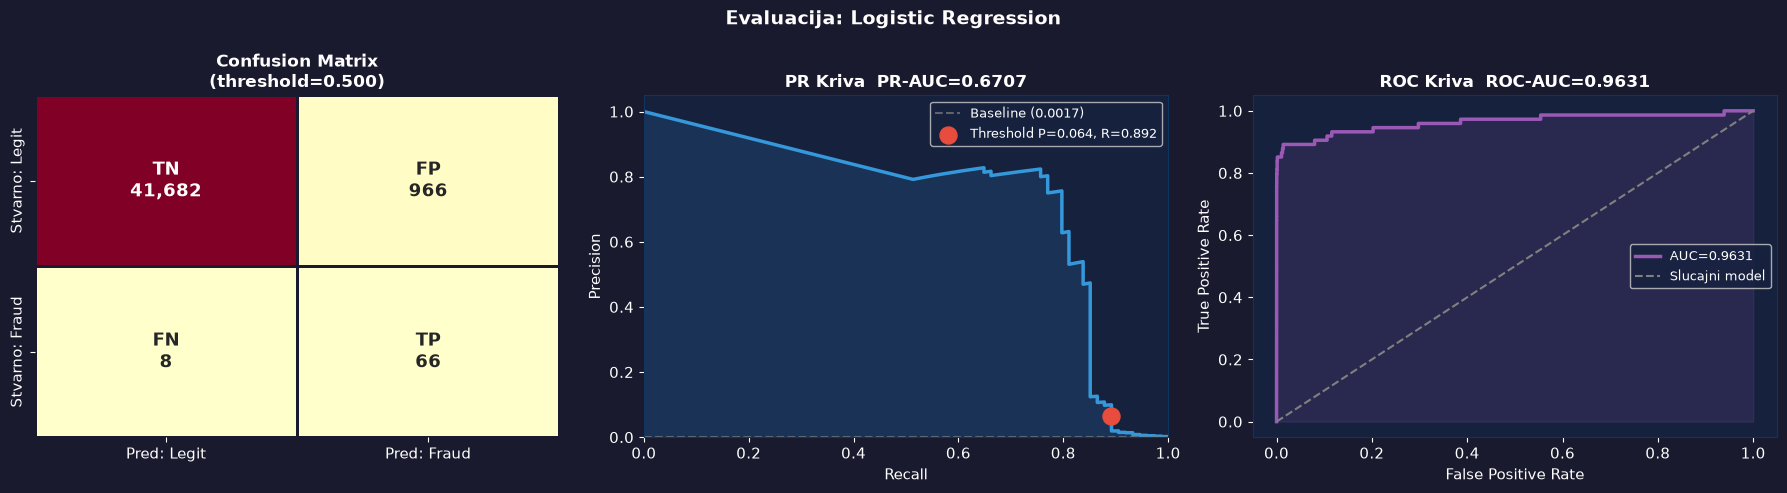


ZAKLJUCAK:
  Logisticka regresija sa balanced weights pokazuje dobar recall.
  Neuronske mreze bi trebale nadjacati ovaj benchmark zahvaljujuci
  sposobnosti ucenja nelinearnih obrazaca u podacima.


In [18]:
# ============================================================
# 7. LOGISTICKA REGRESIJA
# ============================================================

print('Treniranje Logistic Regression modela...')

lr_model = LogisticRegression(
    class_weight='balanced',  # Automatsko balansiranje klasa
    max_iter=1000, random_state=SEED,
    C=0.1, solver='lbfgs'     # L2 regularizacija
)
lr_model.fit(X_train, y_train)
print('Model istreniran.')

# Prikaz izracunatih class weights
cls = np.unique(y_train)
wts = compute_class_weight('balanced', classes=cls, y=y_train)
print(f'\nClass weights:')
print(f'  Legitimne (0): {wts[0]:.4f}')
print(f'  Prevare    (1): {wts[1]:.4f}')
print(f'  Odnos: {wts[1]/wts[0]:.0f}x veca kazna za propustenu prevaru.')

y_prob_lr = lr_model.predict_proba(X_test)[:, 1]
y_pred_lr = (y_prob_lr >= 0.5).astype(int)

evaluate_model('Logistic Regression', y_test, y_pred_lr, y_prob_lr, ALL_RESULTS)

print('\nZAKLJUCAK:')
print('  Logisticka regresija sa balanced weights pokazuje dobar recall.')
print('  Neuronske mreze bi trebale nadjacati ovaj benchmark zahvaljujuci')
print('  sposobnosti ucenja nelinearnih obrazaca u podacima.')


## 8. Basic MLP -- Neuronska Mreza Bez Balansiranja

### Sta demonstriramo?

Ovaj model ima **identicnu arhitekturu** kao Weighted MLP, ali se trenira
**bez ikakve kompenzacije za nebalansiranost klasa**.

Cilj: pokazati da gradijentni spust minimizira ukupni loss, pa model **ignorise
fraud transakcije** (samo 0.17%) jer je lakse minimizirati gre ske na
legitimnim transakcijama (99.83%).

> **Pedagoska vrednost:** Ovaj eksperiment motivise i opravdava upotrebu class weighting i SMOTE.

### Arhitektura MLP
```
Input(30)
  -> Dense(64) -> BatchNorm -> ELU -> Dropout(0.3)
  -> Dense(32) -> BatchNorm -> ELU -> Dropout(0.3)
  -> Dense(16) -> BatchNorm -> ELU -> Dropout(0.3)
  -> Dense(1, sigmoid)
```


Treniranje Basic MLP modela (BEZ class weighting)...
Ocekivanje: los Recall zbog ignorisanja class imbalance!

Epoch 1/100
390/390 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9282 - loss: 0.2473 - pr_auc: 0.0378 - precision: 0.0078 - recall: 0.3227 - val_accuracy: 0.9992 - val_loss: 0.0408 - val_pr_auc: 0.6793 - val_precision: 0.8125 - val_recall: 0.7027 - learning_rate: 0.0010
Epoch 2/100
390/390 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9941 - loss: 0.0522 - pr_auc: 0.3499 - precision: 0.1515 - recall: 0.5233 - val_accuracy: 0.9994 - val_loss: 0.0163 - val_pr_auc: 0.7244 - val_precision: 0.8310 - val_recall: 0.7973 - learning_rate: 0.0010
Epoch 3/100
390/390 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9977 - loss: 0.0265 - pr_auc: 0.5115 - precision: 0.3926 - recall: 0.6163 - val_accuracy: 0.9994 - val_loss: 0.0127 - val_pr_auc: 0.7524 - val_precision: 0.8333 - val_recall: 0.8108 - learning_rate: 0.0010
Epoch 4/100
390/390 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.998

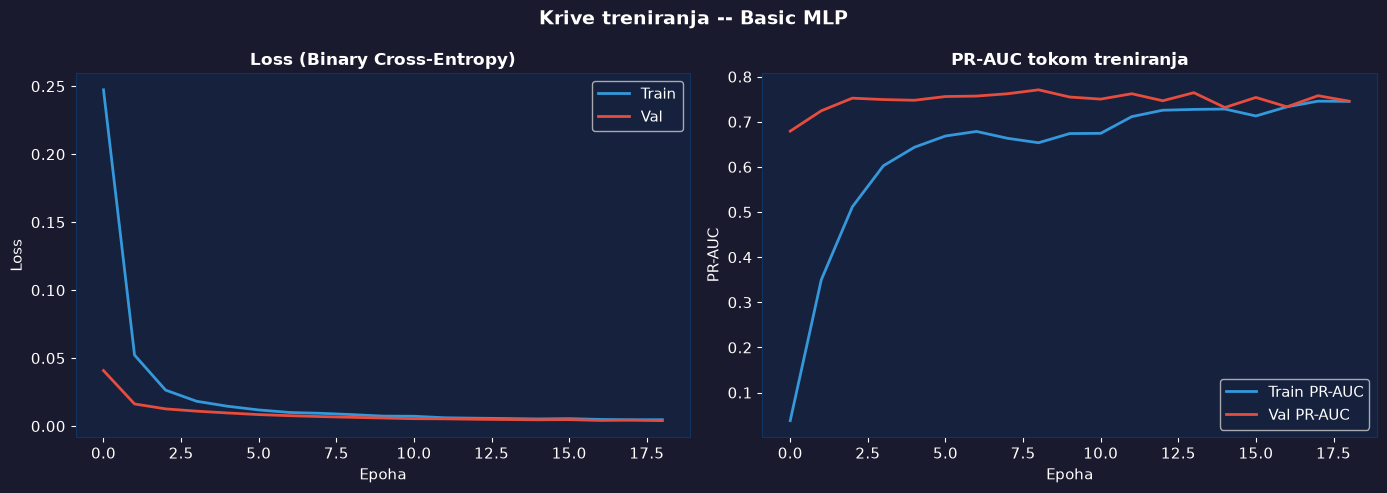


  REZULTATI: Basic MLP
  Threshold:  0.5000
  Precision:  0.7564  (od predvidjenih fraud, 75.6% su stvarno fraud)
  Recall:     0.7973  (pronasli smo 79.7% svih pravih prevara)
  F1-Score:   0.7763
  PR-AUC:     0.6954
  ROC-AUC:    0.9677

  Classification Report:
              precision    recall  f1-score   support

   Legitimno       1.00      1.00      1.00     42648
     Prevara       0.76      0.80      0.78        74

    accuracy                           1.00     42722
   macro avg       0.88      0.90      0.89     42722
weighted avg       1.00      1.00      1.00     42722



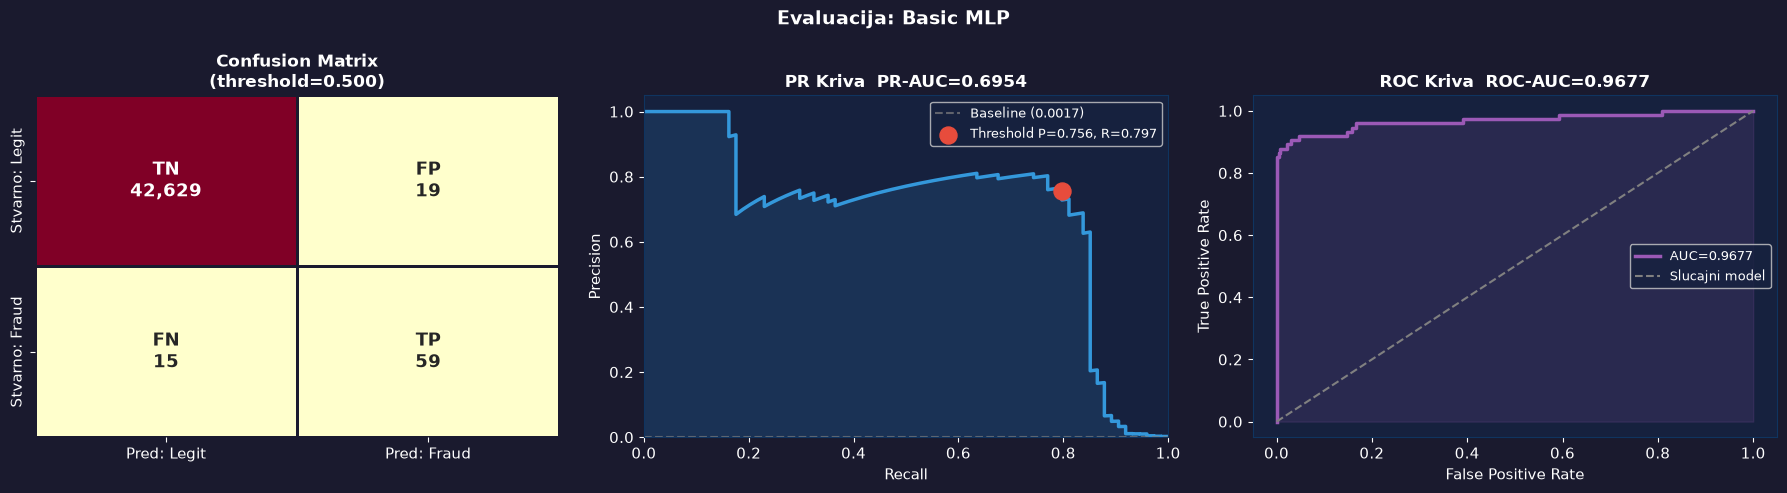


ZAKLJUCAK:
  Basic MLP BEZ class weightinga ima nizak Recall.
  Model ignorise fraud transakcije jer je lakse minimizirati loss
  uvijek predvidjajuci legitimne transakcije (99.83% su legitimne).
  Upravo ovo rjesava class weighting!


In [19]:
# ============================================================
# 8. BASIC MLP (bez class weighting)
# ============================================================

print('Treniranje Basic MLP modela (BEZ class weighting)...')
print('Ocekivanje: los Recall zbog ignorisanja class imbalance!\n')

basic_mlp = build_mlp(INPUT_DIM, name='Basic_MLP')

# Treniranje bez class_weight parametra
history_basic = basic_mlp.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=512,
    callbacks=get_callbacks(), verbose=1
)

print('\nTreniranje zavrseno!')
plot_training(history_basic, 'Basic MLP')

y_prob_basic = basic_mlp.predict(X_test, verbose=0).flatten()
y_pred_basic = (y_prob_basic >= 0.5).astype(int)

evaluate_model('Basic MLP', y_test, y_pred_basic, y_prob_basic, ALL_RESULTS)

print('\nZAKLJUCAK:')
print('  Basic MLP BEZ class weightinga ima nizak Recall.')
print('  Model ignorise fraud transakcije jer je lakse minimizirati loss')
print('  uvijek predvidjajuci legitimne transakcije (99.83% su legitimne).')
print('  To bi trebalo da resi class weighting u sledecem koraku.')


## 9. Weighted MLP -- Neuronska Mreza Sa Ponderisanjem Klasa

### Sta je Class Weighting?

Weighted binary cross-entropy funkcija gubitka:

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N}\left[w_1 y_i \log\hat{y}_i + w_0(1-y_i)\log(1-\hat{y}_i)\right]$$

Greska na fraud primeru prima ~289x veci gradijent.
Model je **prinudjen da nauci karakteristike fraud transakcija**.

U Kerasu, ovo je samo jedan parametar u `.fit()`: `class_weight=class_weight_dict`


Treniranje Weighted MLP modela (SA class weighting)...

Class weights:
  w[0] = 0.5009  (legitimne)
  w[1] = 289.7616  (prevare)
  -> Greska na fraud primjeru je 579x skuplja!

Epoch 1/100
390/390 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7219 - loss: 0.4118 - pr_auc: 0.2554 - precision: 0.0054 - recall: 0.8808 - val_accuracy: 0.9077 - val_loss: 0.3364 - val_pr_auc: 0.5563 - val_precision: 0.0179 - val_recall: 0.9730 - learning_rate: 0.0010
Epoch 2/100
390/390 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8989 - loss: 0.2540 - pr_auc: 0.3666 - precision: 0.0154 - recall: 0.9157 - val_accuracy: 0.9598 - val_loss: 0.2045 - val_pr_auc: 0.5964 - val_precision: 0.0392 - val_recall: 0.9459 - learning_rate: 0.0010
Epoch 3/100
390/390 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9377 - loss: 0.1990 - pr_auc: 0.4486 - precision: 0.0250 - recall: 0.9244 - val_accuracy: 0.9731 - val_loss: 0.1479 - val_pr_auc: 0.6964 - val_precision: 0.0555 - val_recall: 0.9054 - learning_rate: 0.0010
Epoc

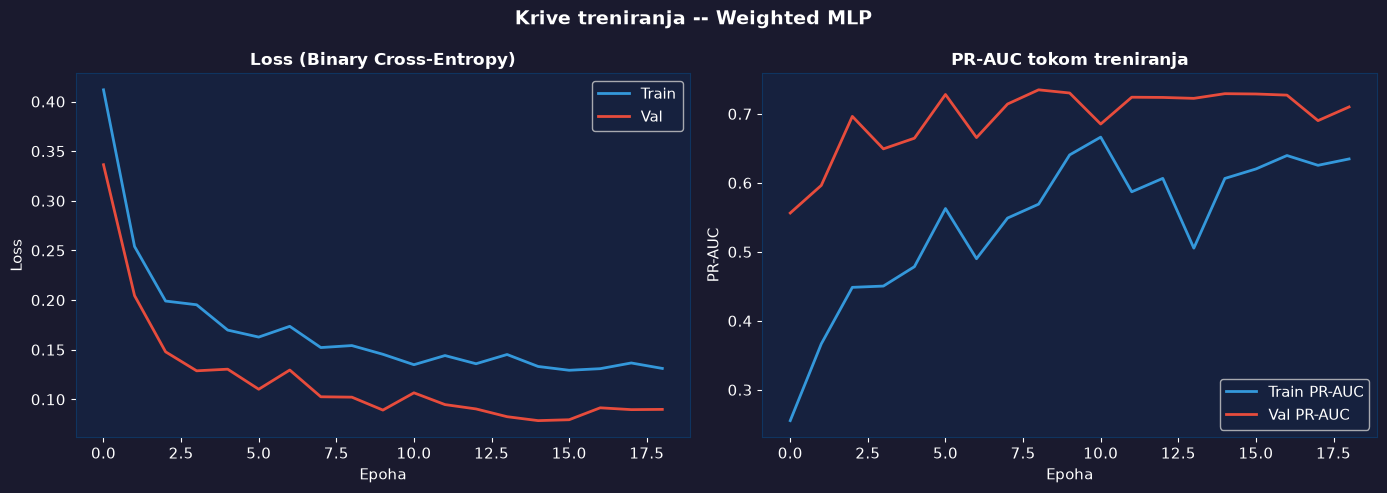


  REZULTATI: Weighted MLP
  Threshold:  0.5000
  Precision:  0.0544  (od predvidjenih fraud, 5.4% su stvarno fraud)
  Recall:     0.8784  (pronasli smo 87.8% svih pravih prevara)
  F1-Score:   0.1025
  PR-AUC:     0.6510
  ROC-AUC:    0.9713

  Classification Report:
              precision    recall  f1-score   support

   Legitimno       1.00      0.97      0.99     42648
     Prevara       0.05      0.88      0.10        74

    accuracy                           0.97     42722
   macro avg       0.53      0.93      0.54     42722
weighted avg       1.00      0.97      0.98     42722



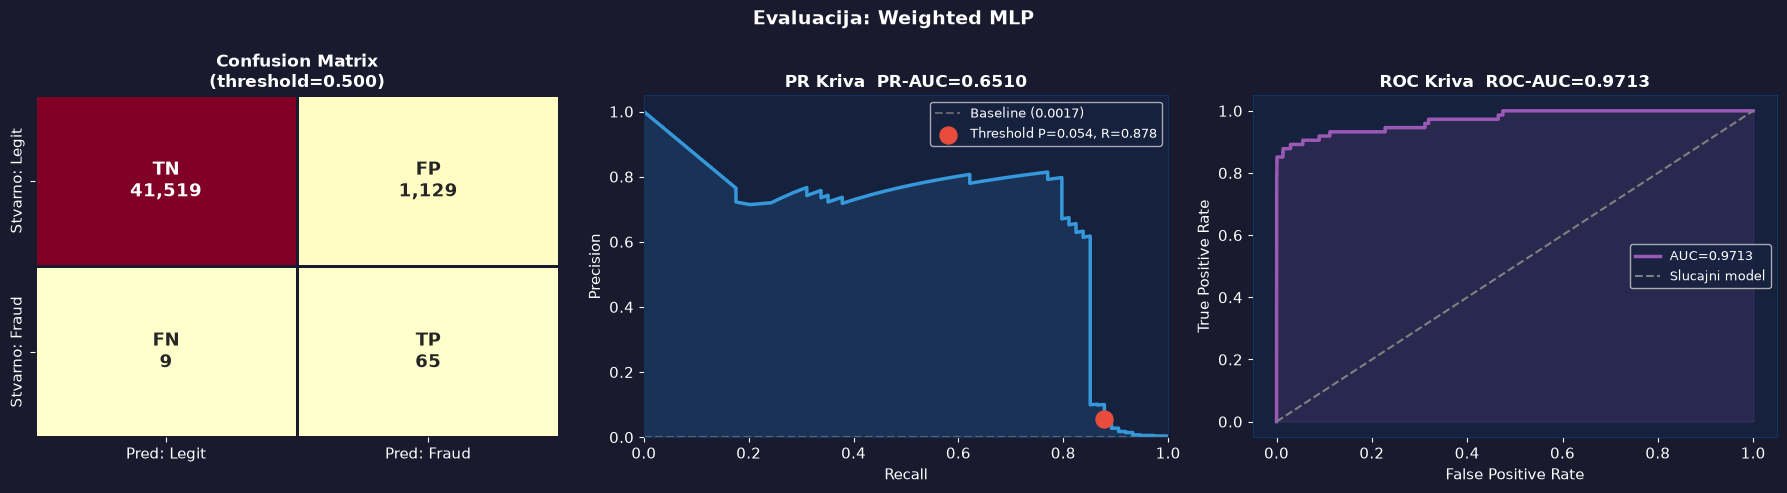


ZAKLJUCAK:
  Weighted MLP pokazuje ZNACAJNO POBOLJSANJE u Recall!
  Samo jedan parametar (class_weight) drasticno mijenja sposobnost modela
  da detektuje prevare. Sljedeci korak: threshold tuning!


In [20]:
# ============================================================
# 9. WEIGHTED MLP (sa class weighting)
# ============================================================

print('Treniranje Weighted MLP modela (SA class weighting)...')

cls = np.unique(y_train)
wts = compute_class_weight('balanced', classes=cls, y=y_train)
class_weight_dict = dict(zip(cls, wts))

print(f'\nClass weights:')
print(f'  w[0] = {class_weight_dict[0]:.4f}  (legitimne)')
print(f'  w[1] = {class_weight_dict[1]:.4f}  (prevare)')
print(f'  -> Greska na fraud primeru je {class_weight_dict[1]/class_weight_dict[0]:.0f}x skuplja!\n')

weighted_mlp = build_mlp(INPUT_DIM, name='Weighted_MLP')

# Jedina razlika od Basic MLP: class_weight parametar!
history_weighted = weighted_mlp.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=512,
    class_weight=class_weight_dict,  # <- kljucna razlika
    callbacks=get_callbacks(), verbose=1
)

print('\nTreniranje zavrseno!')
plot_training(history_weighted, 'Weighted MLP')

y_prob_weighted = weighted_mlp.predict(X_test, verbose=0).flatten()
y_pred_weighted = (y_prob_weighted >= 0.5).astype(int)

evaluate_model('Weighted MLP', y_test, y_pred_weighted, y_prob_weighted, ALL_RESULTS)

print('\nZAKLJUCAK:')
print('  Weighted MLP pokazuje vidno poboljsanje u Recall-u u odnosu na Basic MLP.')
print('  Samo jedan parametar (class_weight) drasticno menja sposobnost modela')
print('  da detektuje prevare. Sledeci korak je threshold tuning.')


## 10. Podesavanje Praga Klasifikacije (Threshold Tuning)

### Sta je Threshold Tuning?

Neuronska mreza daje **verovatnoce** u [0, 1]. Standard: `fraud if P >= 0.5`.
Ali prag **0.5 nije uvijek optimalan!**

| Akcija | Recall | Precision | Efekat |
|---|---|---|---|
| t smanjimo | raste | pada | Vise prevara otkriveno, vise laznih alarma |
| t povecamo | pada | raste | Manje laznih alarma, propustamo vise prevara |

### Nalazenje optimalnog praga

Maksimiziramo F1-Score na **validacionom skupu**:

$$t^* = \arg\max_t\; F1(t) = \arg\max_t\; \frac{2 P(t) R(t)}{P(t) + R(t)}$$

> **Nikad** ne koristiti test skup za threshold tuning -- to bi bio **data leakage**!


Trazenje optimalnog threshold-a na validacionom skupu...

Optimalni prag pronadjen!
  Standardni prag: 0.5000
  Optimalni prag:  0.9984
  Na optimalnom pragu (val skup):
  Precision: 0.8824  Recall: 0.8108  F1: 0.8451


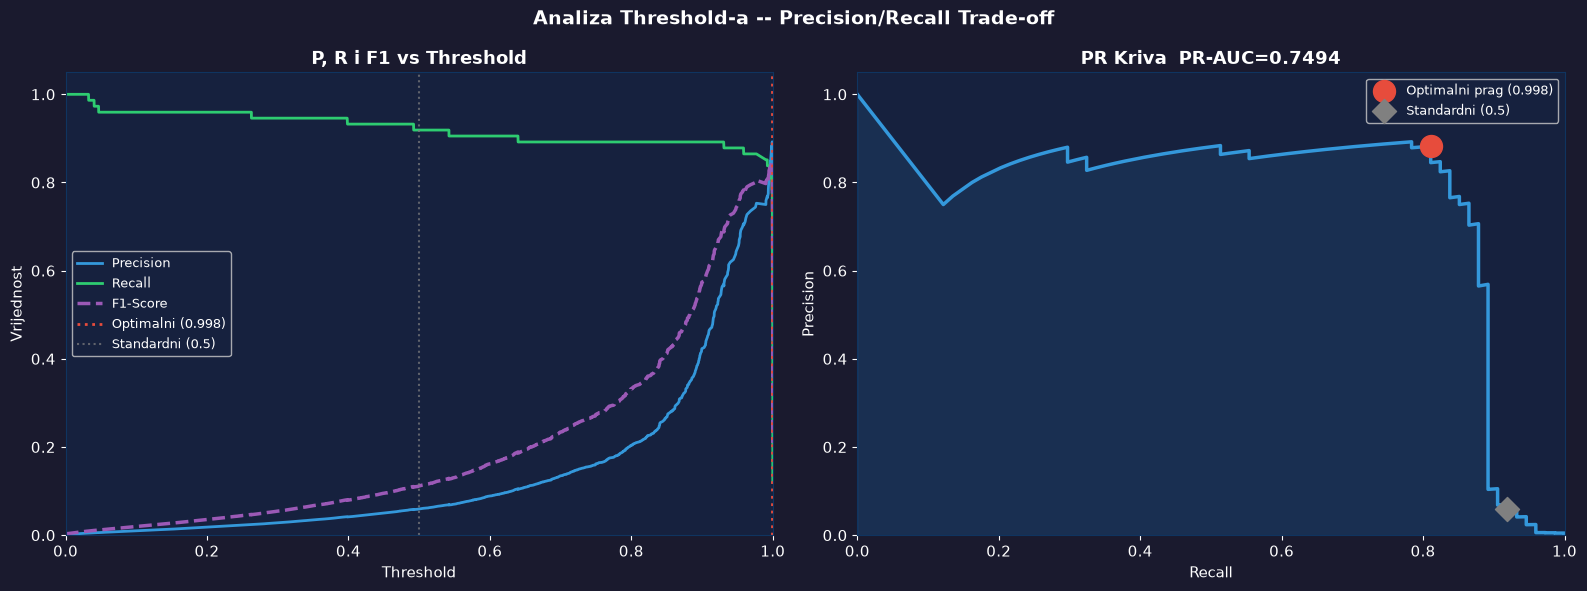


  REZULTATI: Weighted MLP + Threshold
  Threshold:  0.9984
  Precision:  0.7917  (od predvidjenih fraud, 79.2% su stvarno fraud)
  Recall:     0.7703  (pronasli smo 77.0% svih pravih prevara)
  F1-Score:   0.7808
  PR-AUC:     0.6510
  ROC-AUC:    0.9713

  Classification Report:
              precision    recall  f1-score   support

   Legitimno       1.00      1.00      1.00     42648
     Prevara       0.79      0.77      0.78        74

    accuracy                           1.00     42722
   macro avg       0.90      0.88      0.89     42722
weighted avg       1.00      1.00      1.00     42722



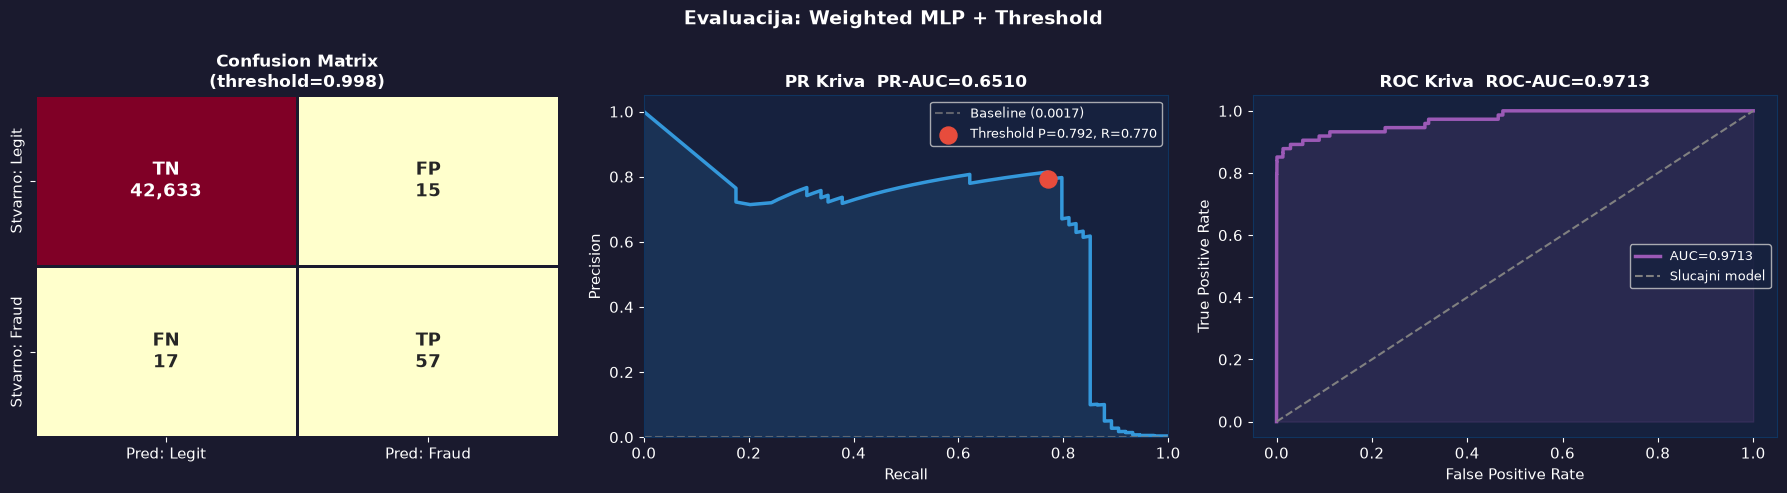


ZAKLJUCAK:
  Smanjenjem praga sa 0.5 na 0.9984:
  -> Recall se povecao (detektujemo vise prevara)
  -> Precision se blago smanjio (prihvatljiv trade-off)
  -> Prag biramo prema poslovnom cilju (troskovi FN vs FP)!


In [21]:
# ============================================================
# 10. THRESHOLD TUNING
# ============================================================

print('Trazenje optimalnog threshold-a na validacionom skupu...')

# Predvidjamo na VALIDACIONOM skupu - nikad na test skupu!
y_prob_val = weighted_mlp.predict(X_val, verbose=0).flatten()

# P, R i thresholds za sve moguce pragove
prec_v, rec_v, thresh_v = precision_recall_curve(y_val, y_prob_val)

# F1 za svaki prag (izbegavamo deljenje nulom)
f1_v = np.where(
    (prec_v[:-1] + rec_v[:-1]) > 0,
    2 * prec_v[:-1] * rec_v[:-1] / (prec_v[:-1] + rec_v[:-1]),
    0
)

opt_idx       = np.argmax(f1_v)
opt_threshold = thresh_v[opt_idx]
opt_p, opt_r, opt_f1 = prec_v[opt_idx], rec_v[opt_idx], f1_v[opt_idx]

print(f'\nOptimalni prag je pronadjen:')
print(f'  Standardni prag: 0.5000')
print(f'  Optimalni prag:  {opt_threshold:.4f}')
print(f'  Na optimalnom pragu (val skup):')
print(f'  Precision: {opt_p:.4f}  Recall: {opt_r:.4f}  F1: {opt_f1:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analiza Threshold-a -- Precision/Recall Trade-off', fontsize=14, fontweight='bold')
for ax in axes:
    ax.set_facecolor('#16213e')

axes[0].plot(thresh_v, prec_v[:-1], color=PRIMARY_COLOR,   linewidth=2, label='Precision')
axes[0].plot(thresh_v, rec_v[:-1],  color=LEGIT_COLOR,     linewidth=2, label='Recall')
axes[0].plot(thresh_v, f1_v,        color=SECONDARY_COLOR, linewidth=2.5, linestyle='--', label='F1-Score')
axes[0].axvline(x=opt_threshold, color=FRAUD_COLOR, linewidth=2, linestyle=':',
                label=f'Optimalni ({opt_threshold:.3f})')
axes[0].axvline(x=0.5, color='gray', linewidth=1.5, linestyle=':', alpha=0.7,
                label='Standardni (0.5)')
axes[0].set_title('P, R i F1 vs Threshold', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Vrednost')
axes[0].legend(fontsize=9); axes[0].set_xlim([0,1]); axes[0].set_ylim([0,1.05])

pr_auc_v = average_precision_score(y_val, y_prob_val)
axes[1].plot(rec_v, prec_v, color=PRIMARY_COLOR, linewidth=2.5)
axes[1].fill_between(rec_v, prec_v, alpha=0.12, color=PRIMARY_COLOR)
axes[1].scatter([opt_r], [opt_p], color=FRAUD_COLOR, s=250, zorder=6,
                label=f'Optimalni prag ({opt_threshold:.3f})')
idx_05 = np.argmin(np.abs(thresh_v - 0.5))
axes[1].scatter([rec_v[idx_05]], [prec_v[idx_05]], color='gray', s=150, marker='D', zorder=5,
                label='Standardni (0.5)')
axes[1].set_title(f'PR Kriva  PR-AUC={pr_auc_v:.4f}', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9); axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.05])

plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

# Primena optimalnog threshold-a na TEST skup
y_pred_tuned = (y_prob_weighted >= opt_threshold).astype(int)
evaluate_model('Weighted MLP + Threshold', y_test, y_pred_tuned,
               y_prob_weighted, ALL_RESULTS, threshold=opt_threshold)

print(f'\nZAKLJUCAK:')
print(f'  Smanjenjem praga sa 0.5 na {opt_threshold:.4f}:')
print(f'  -> Recall se povecao (detektujemo vise prevara)')
print(f'  -> Precision se blago smanjio (prihvatljiv trade-off)')
print(f'  -> Prag biramo prema poslovnom cilju (u zavisnosti od odnosa troska FN i FP).')


## 11. SMOTE -- Sinteticko Uvecanje Podataka

**SMOTE** (Synthetic Minority Over-sampling Technique, Chawla et al., 2002)
kreira **nove sinteticke fraud primere** interpolacijom:

```
Za svaki fraud primer x_i:
  1. Pronadji K=5 najblizih fraud suseda
  2. Nasumicno odaberi suseda x_j
  3. x_new = x_i + lambda * (x_j - x_i),  lambda u [0, 1]
```

### SMOTE vs Class Weighting

| Pristup | Prednost | Nedostatak |
|---|---|---|
| **Class Weighting** | Brz, bez modifikacije podataka | Samo menja loss |
| **SMOTE** | Kreira nove informacije; bolja generalizacija | Sporiji; rizik overfittinga |

> **Pravilo:** SMOTE se primenjuje ISKLJUCIVO na **trening skup**!
> Validacioni i test skupovi moraju ostati originalni -- bez **data leakage**-a.


Primjena SMOTE na trening skup...

  PRIJE SMOTE:
  Legitimne: 199,012  |  Prevare: 344
  Omjer: 579:1

  NAKON SMOTE:
  Legitimne: 199,012  |  Prevare: 99,506
  Kreirano novih sintetickih fraud primjera: +99,162


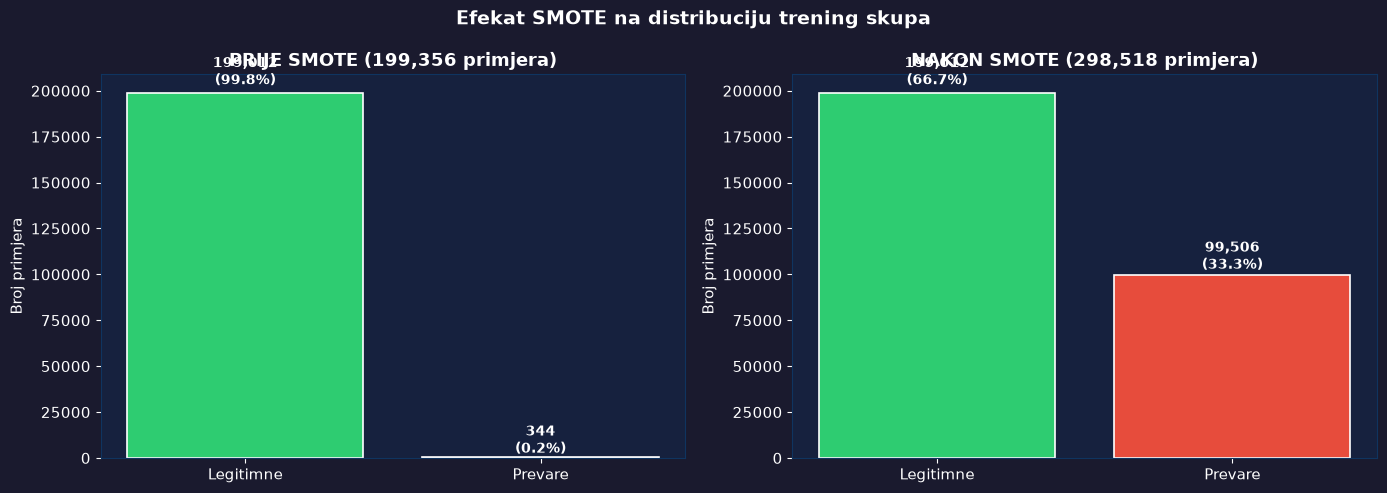


Treniranje MLP na SMOTE datasetu...
  Validacija na ORIGINALNIM podacima (bez data leakage)!

Epoch 1/100
584/584 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9519 - loss: 0.1538 - pr_auc: 0.9746 - precision: 0.9572 - recall: 0.8959 - val_accuracy: 0.9853 - val_loss: 0.0643 - val_pr_auc: 0.7788 - val_precision: 0.0984 - val_recall: 0.9189 - learning_rate: 0.0010
Epoch 2/100
584/584 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9646 - loss: 0.1078 - pr_auc: 0.9865 - precision: 0.9665 - recall: 0.9258 - val_accuracy: 0.9898 - val_loss: 0.0483 - val_pr_auc: 0.7931 - val_precision: 0.1368 - val_recall: 0.9189 - learning_rate: 0.0010
Epoch 3/100
584/584 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9682 - loss: 0.0919 - pr_auc: 0.9902 - precision: 0.9671 - recall: 0.9366 - val_accuracy: 0.9913 - val_loss: 0.0398 - val_pr_auc: 0.7552 - val_precision: 0.1567 - val_recall: 0.9189 - learning_rate: 0.0010
Epoch 4/100
584/584 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9712 - loss: 0.0819

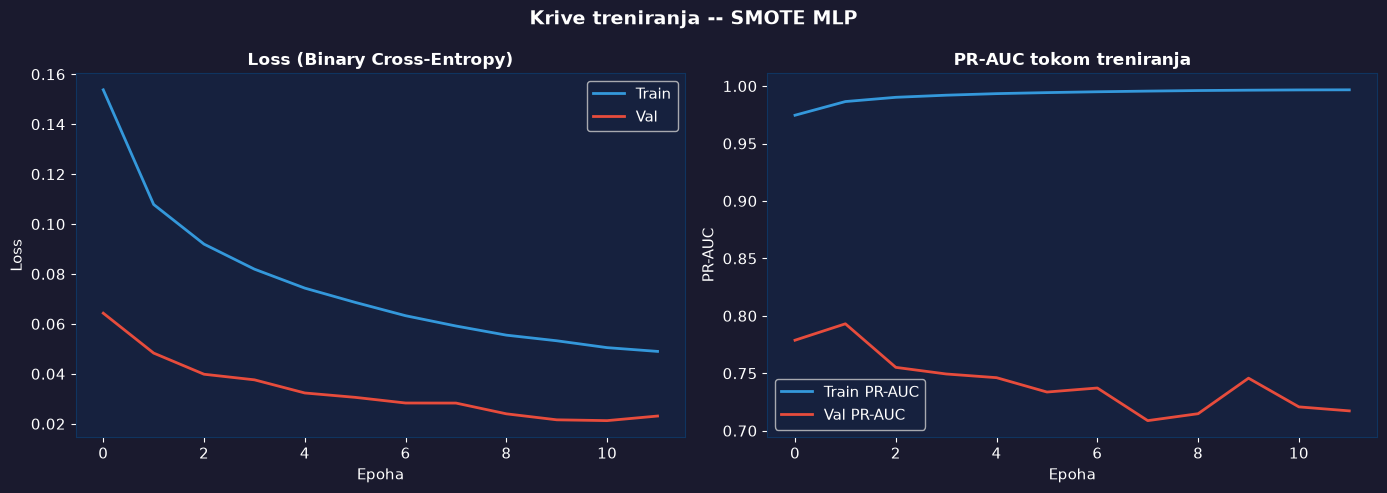


  REZULTATI: SMOTE + MLP
  Threshold:  0.5000
  Precision:  0.1248  (od predvidjenih fraud, 12.5% su stvarno fraud)
  Recall:     0.8784  (pronasli smo 87.8% svih pravih prevara)
  F1-Score:   0.2185
  PR-AUC:     0.7162
  ROC-AUC:    0.9747

  Classification Report:
              precision    recall  f1-score   support

   Legitimno       1.00      0.99      0.99     42648
     Prevara       0.12      0.88      0.22        74

    accuracy                           0.99     42722
   macro avg       0.56      0.93      0.61     42722
weighted avg       1.00      0.99      0.99     42722



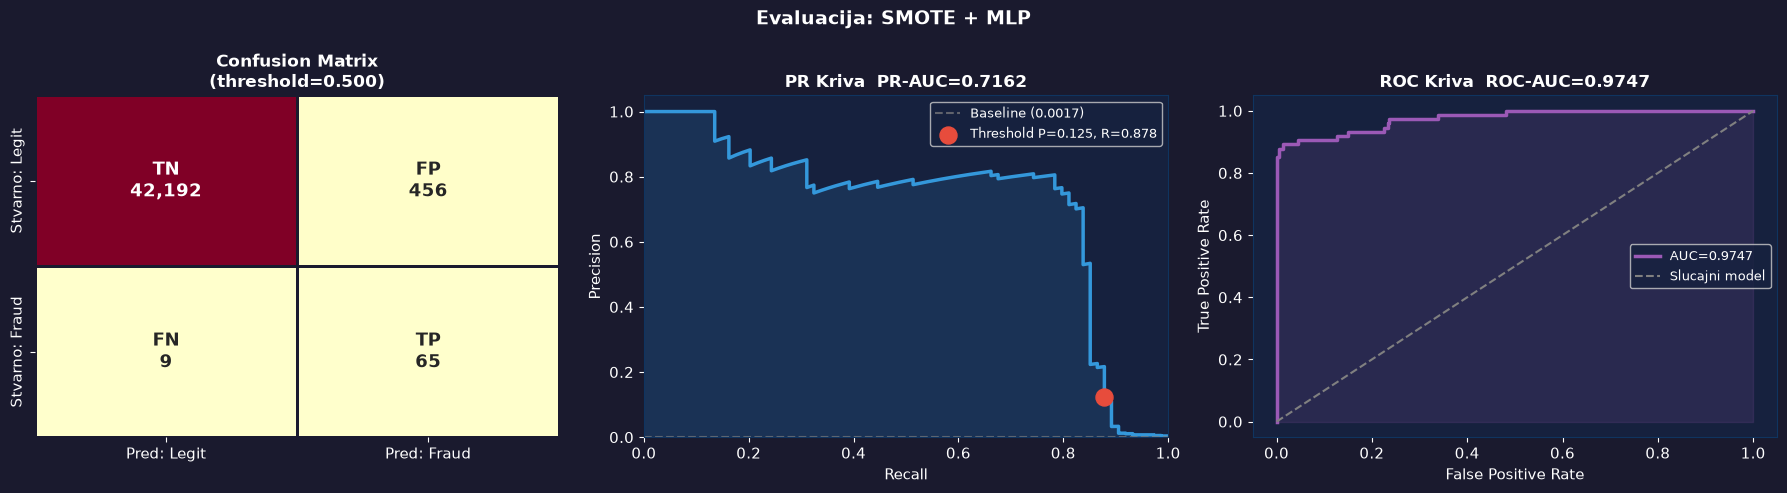


ZAKLJUCAK:
  SMOTE kreira sinteticke primjere koji pomazu modelu da bolje razumije
  karakteristike fraud transakcija. Poredenje sa Weighted MLP-om pokazuje
  koja tehnika daje bolje rezultate na ovom datasetu.


In [22]:
# ============================================================
# 11. SMOTE + MLP
# ============================================================

print('Primena SMOTE na trening skup...')
print(f'\n  PRE SMOTE:')
print(f'  Legitimne: {(y_train==0).sum():,}  |  Prevare: {(y_train==1).sum():,}')
print(f'  Odnos: {(y_train==0).sum()/(y_train==1).sum():.0f}:1')

# sampling_strategy=0.5 => n_fraud = 0.5 * n_legit nakon resample-a
smote = SMOTE(sampling_strategy=0.5, random_state=SEED, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

n_new = (y_train_sm==1).sum() - (y_train==1).sum()
print(f'\n  NAKON SMOTE:')
print(f'  Legitimne: {(y_train_sm==0).sum():,}  |  Prevare: {(y_train_sm==1).sum():,}')
print(f'  Kreirano novih sintetickih fraud primera: +{n_new:,}')

# Vizualizacija efekta SMOTE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Efekat SMOTE na distribuciju trening skupa', fontsize=14, fontweight='bold')
for ax in axes:
    ax.set_facecolor('#16213e')

for idx, (y_d, title) in enumerate([
    (y_train,    f'PRE SMOTE ({len(y_train):,} primera)'),
    (y_train_sm, f'NAKON SMOTE ({len(y_train_sm):,} primera)')
]):
    cnts = np.bincount(y_d)
    bars = axes[idx].bar(['Legitimne', 'Prevare'], cnts,
                         color=[LEGIT_COLOR, FRAUD_COLOR], edgecolor='white', linewidth=1.2)
    for bar, cnt in zip(bars, cnts):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                       f'{cnt:,}\n({cnt/len(y_d)*100:.1f}%)',
                       ha='center', va='bottom', fontsize=10, fontweight='bold')
    axes[idx].set_title(title, fontsize=13, fontweight='bold')
    axes[idx].set_ylabel('Broj primera')

plt.tight_layout()
plt.savefig('smote_effect.png', dpi=150, bbox_inches='tight')
plt.show()

# Treniranje MLP na SMOTE datasetu
print('\nTreniranje MLP na SMOTE datasetu...')
print('  Validacija na ORIGINALNIM podacima (bez data leakage)!\n')

smote_mlp = build_mlp(INPUT_DIM, name='SMOTE_MLP')
history_smote = smote_mlp.fit(
    X_train_sm, y_train_sm,          # SMOTE trening podaci
    validation_data=(X_val, y_val),   # Originalni val podaci!
    epochs=100, batch_size=512,
    callbacks=get_callbacks(), verbose=1
)

print('\nSMOTE MLP treniranje zavrseno!')
plot_training(history_smote, 'SMOTE MLP')

y_prob_smote = smote_mlp.predict(X_test, verbose=0).flatten()
y_pred_smote = (y_prob_smote >= 0.5).astype(int)

evaluate_model('SMOTE + MLP', y_test, y_pred_smote, y_prob_smote, ALL_RESULTS)

print('\nZAKLJUCAK:')
print('  SMOTE kreira sinteticke primere koji pomazu modelu da bolje razume')
print('  karakteristike fraud transakcija. Poredenje sa Weighted MLP-om pokazuje')
print('  koja tehnika daje bolje rezultate na ovom datasetu.')


## 12. Autoencoder -- Unsupervised Detekcija Anomalija

### Potpuno drugaciji pristup!

Autoencoder koristi **unsupervised** pristup:

1. Trenira se **SAMO na legitimnim transakcijama** -- uci sta je 'normalno'
2. Za svaku novu transakciju, pokusava je rekonstruisati
3. **Legitimne** -> mali reconstruction error (model ih dobro rekonstruise)
4. **Fraud** -> **veliki reconstruction error** (razlikuju se od 'normalnog')

### Arhitektura Autoencoder-a
```
Input(30) -> Dense(32)->BN->ELU -> Dense(16)->BN->ELU -> Dense(8) [latentni prostor]
          -> Dense(16)->BN->ELU -> Dense(32)->BN->ELU -> Dense(30) [rekonstrukcija]
```

**Loss:** MSE izmedju originalnog i rekonstruisanog vektora

| | Detalj |
|---|---|
| **Unsupervised** | Ne treba fraud labele za treniranje |
| **Generalizacija** | Robustan na nove, nevidjene vrste prevara |
| **Slabost** | Losiji PR-AUC od supervised modela kada postoje labele |


Izgradnja Autoencoder modela...
  Legitimnih za treniranje: 199,012
  (Autoencoder ne vidi fraud primjere tokom treniranja!)



Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu (ELU)                       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu_1 (ELU)                     │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu_2 (ELU)                     │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu_3 (ELU)                     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 30)             │           990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,622 (14.15 KB)

 Trainable params: 3,430 (13.40 KB)

 Non-trainable params: 192 (768.00 B)


Kompresija: 30 -> 8 -> 30  (3x faktor)

Treniranje autoencodera...

Epoch 1/100
778/778 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.6071 - val_loss: 0.4134 - learning_rate: 0.0010
Epoch 2/100
778/778 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3857 - val_loss: 0.3112 - learning_rate: 0.0010
Epoch 3/100
778/778 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3345 - val_loss: 0.2750 - learning_rate: 0.0010
Epoch 4/100
778/778 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3079 - val_loss: 0.2515 - learning_rate: 0.0010
Epoch 5/100
778/778 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2912 - val_loss: 0.2391 - learning_rate: 0.0010
Epoch 6/100
778/778 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2799 - val_loss: 0.2276 - learning_rate: 0.0010
Epoch 7/100
778/778 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2729 - val_loss: 0.2226 - learning_rate: 0.0010
Epoch 8/100
778/778 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2677 - val_loss: 0.2184 - learning_rate: 0.0010
Epoch 9/100
778/778 ━━━━━━━━━━━━━━━━━━━━ 1s

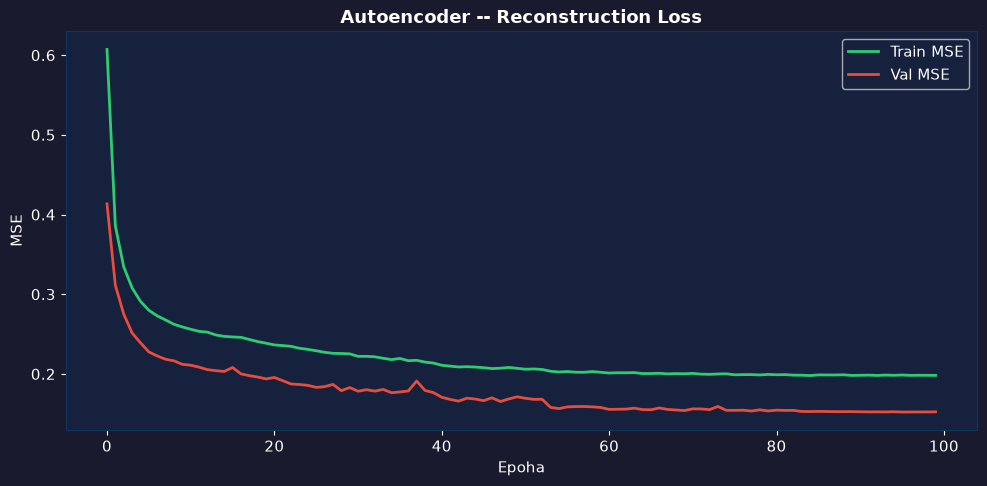

In [23]:
# ============================================================
# 12. AUTOENCODER ZA DETEKCIJU ANOMALIJA
# ============================================================

print('Izgradnja Autoencoder modela...')

# Treniramo SAMO na legitimnim transakcijama!
X_tr_legit  = X_train[y_train == 0]
X_val_legit = X_val[y_val == 0]

print(f'  Legitimnih za treniranje: {len(X_tr_legit):,}')
print(f'  (Autoencoder ne vidi fraud primere tokom treniranja!)\n')

input_dim = X_train.shape[1]

# ENCODER -- kompresuje podatke u latentni prostor
enc_in = keras.Input(shape=(input_dim,), name='encoder_input')
x = layers.Dense(32, use_bias=False)(enc_in)
x = layers.BatchNormalization()(x)
x = layers.ELU()(x)
x = layers.Dropout(0.1)(x)
x = layers.Dense(16, use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.ELU()(x)

# Latentni prostor -- najuze grlo, komprimovana reprezentacija
latent = layers.Dense(8, activation='tanh', name='latent_space')(x)

# DECODER -- rekonstruise original iz latentnog prostora
x = layers.Dense(16, use_bias=False)(latent)
x = layers.BatchNormalization()(x)
x = layers.ELU()(x)
x = layers.Dense(32, use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.ELU()(x)

# Linearna aktivacija -- rekonstruise vrednosti koje mogu biti negativne
dec_out = layers.Dense(input_dim, activation='linear', name='reconstruction')(x)

autoencoder = keras.Model(enc_in, dec_out, name='Autoencoder')
autoencoder.compile(optimizer=keras.optimizers.Adam(0.001), loss='mse')
autoencoder.summary()
print(f'\nKompresija: {input_dim} -> 8 -> {input_dim}  ({input_dim//8}x faktor)')

# TRENIRANJE -- ulaz = cilj (X -> rekonstruisi X)
print('\nTreniranje autoencodera...\n')
ae_cbs = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=5, min_lr=1e-6, verbose=1)
]

# Kljucno: ulaz i cilj su ISTI (X, X)
history_ae = autoencoder.fit(
    X_tr_legit,  X_tr_legit,
    validation_data=(X_val_legit, X_val_legit),
    epochs=100, batch_size=256,
    callbacks=ae_cbs, verbose=1
)

print('\nAutoencoder treniranje zavrseno!')

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_facecolor('#16213e')
ax.plot(history_ae.history['loss'],     color=LEGIT_COLOR, linewidth=2, label='Train MSE')
ax.plot(history_ae.history['val_loss'], color=FRAUD_COLOR, linewidth=2, label='Val MSE')
ax.set_title('Autoencoder -- Reconstruction Loss', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoha'); ax.set_ylabel('MSE'); ax.legend()
plt.tight_layout()
plt.savefig('autoencoder_training.png', dpi=150, bbox_inches='tight')
plt.show()


Izracunavanje Reconstruction Error-a...
RECONSTRUCTION ERROR ANALIZA:
  Legitimne -- mean: 0.1585  std: 0.6278
  Prevare   -- mean: 17.6368  std: 20.4352
  Omjer: 111.3x veci error za prevare!

  -> Prevare imaju ZNACAJNO veci reconstruction error!
Optimalni threshold (iz VAL skupa): 3.4241


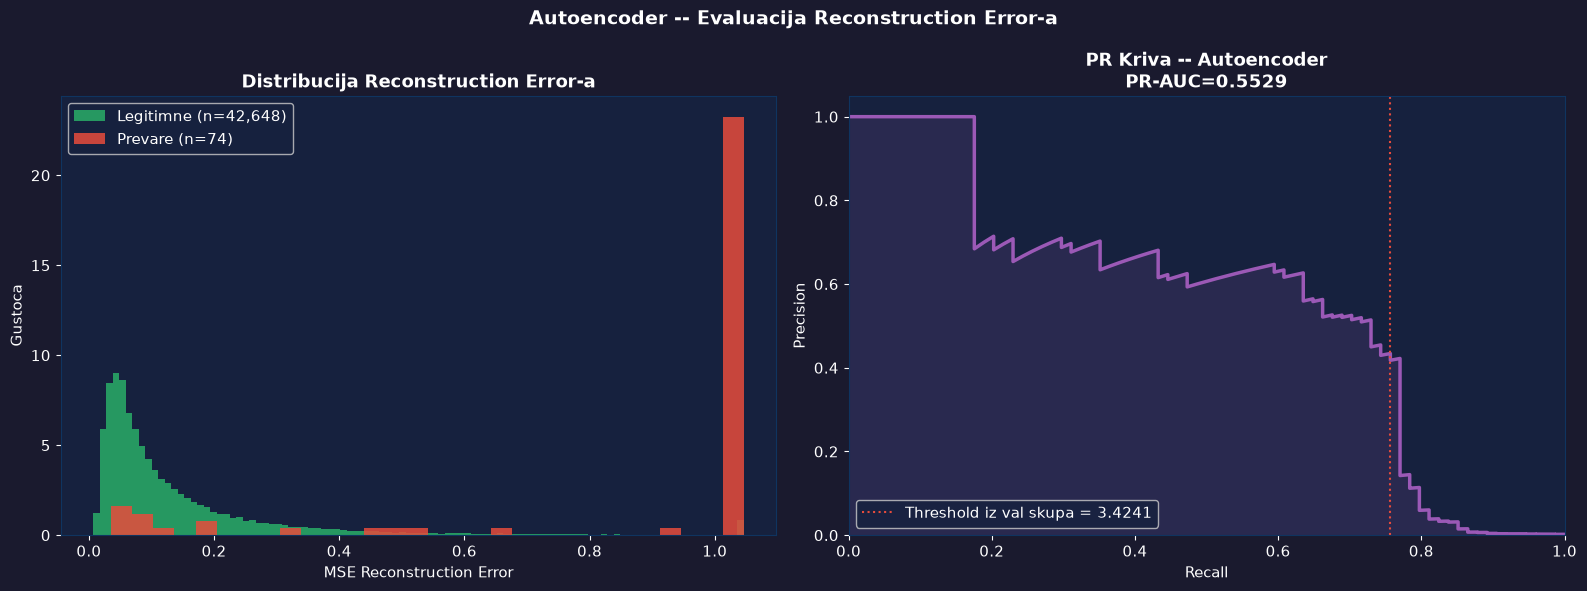


  REZULTATI: Autoencoder
  Threshold:  3.4241
  Precision:  0.4954  (od predvidjenih fraud, 49.5% su stvarno fraud)
  Recall:     0.7297  (pronasli smo 73.0% svih pravih prevara)
  F1-Score:   0.5902
  PR-AUC:     0.5529
  ROC-AUC:    0.9271

  Classification Report:
              precision    recall  f1-score   support

   Legitimno       1.00      1.00      1.00     42648
     Prevara       0.50      0.73      0.59        74

    accuracy                           1.00     42722
   macro avg       0.75      0.86      0.79     42722
weighted avg       1.00      1.00      1.00     42722



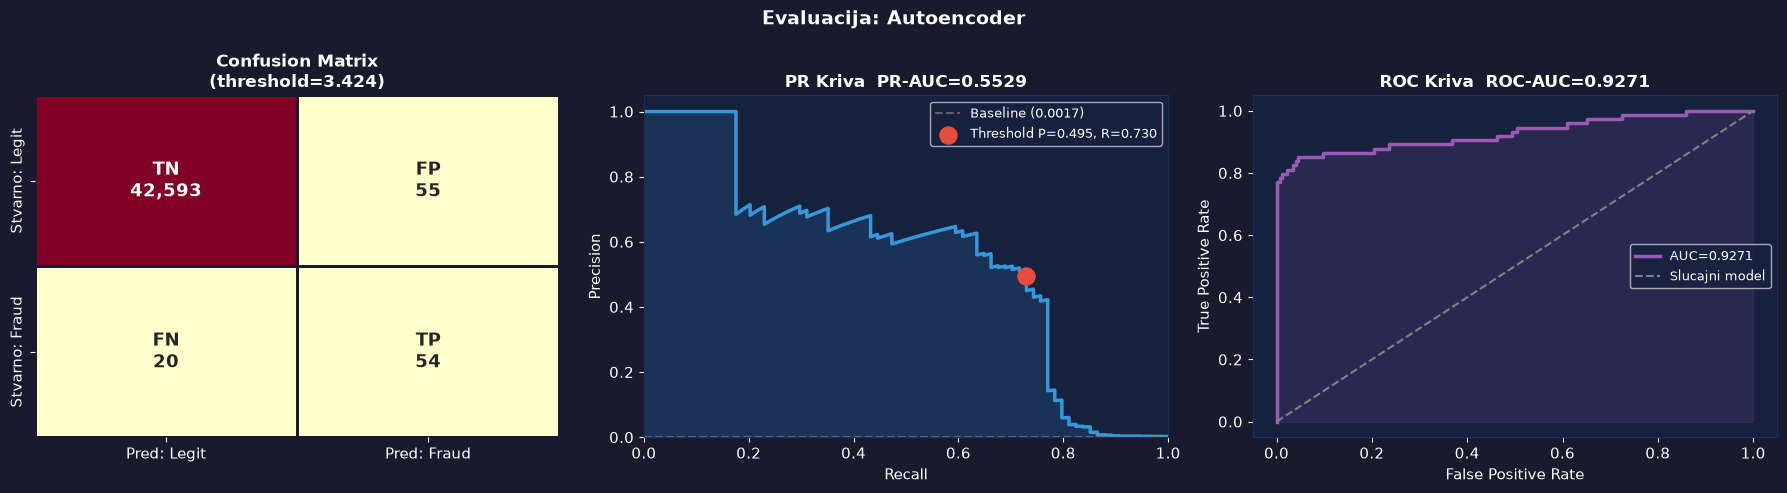

ZAKLJUCAK:
  Autoencoder koristi potpuno drugaciji, unsupervised pristup.
  PR-AUC = 0.5529 -- interesantno ga je uporediti sa supervised modelima.
  Autoencoder je posebno vrijedan kada fraud labele NISU dostupne.


In [24]:
# ============================================================
# EVALUACIJA AUTOENCODERA
# ============================================================

print('Izracunavanje Reconstruction Error-a...')

# Reconstruction error na TEST skupu (za finalnu evaluaciju i grafik)
X_test_recon = autoencoder.predict(X_test, verbose=0)
recon_err    = np.mean(np.square(X_test - X_test_recon), axis=1)
err_fraud    = recon_err[y_test == 1]
err_legit    = recon_err[y_test == 0]

print('RECONSTRUCTION ERROR ANALIZA:')
print(f'  Legitimne -- mean: {err_legit.mean():.4f}  std: {err_legit.std():.4f}')
print(f'  Prevare   -- mean: {err_fraud.mean():.4f}  std: {err_fraud.std():.4f}')
print(f'  Odnos: {err_fraud.mean()/err_legit.mean():.1f}x veci error za prevare.')
print()
print('  -> Prevare imaju vidno veci reconstruction error.')

# ─── THRESHOLD TUNING NA VALIDACIONOM SKUPU ─────────────────────────────
# Konsistentno sa Weighted MLP pristupom (Cell 22): prag trazimo na val skupu,
# a test skup koristimo iskljucivo za finalnu evaluaciju.
# Pogresno bi bilo: precision_recall_curve(y_test, recon_err) -- to je data leakage!
X_val_recon   = autoencoder.predict(X_val, verbose=0)
recon_err_val = np.mean(np.square(X_val - X_val_recon), axis=1)

prec_val_ae, rec_val_ae, thresh_val_ae = precision_recall_curve(y_val, recon_err_val)
f1_val_ae = np.where(
    (prec_val_ae[:-1] + rec_val_ae[:-1]) > 0,
    2 * prec_val_ae[:-1] * rec_val_ae[:-1] / (prec_val_ae[:-1] + rec_val_ae[:-1]),
    0
)
opt_ae   = np.argmax(f1_val_ae)
opt_t_ae = thresh_val_ae[opt_ae]
print(f'Optimalni threshold (iz VAL skupa): {opt_t_ae:.4f}')

# Grafici (PR kriva na test skupu -- samo za vizualizaciju, ne za tuning)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Autoencoder -- Evaluacija Reconstruction Error-a', fontsize=14, fontweight='bold')
for ax in axes:
    ax.set_facecolor('#16213e')

clip_v = np.percentile(recon_err, 99)
axes[0].hist(err_legit.clip(max=clip_v), bins=100, alpha=0.7, color=LEGIT_COLOR, density=True,
             label=f'Legitimne (n={len(err_legit):,})')
axes[0].hist(err_fraud.clip(max=clip_v), bins=30, alpha=0.85, color=FRAUD_COLOR, density=True,
             label=f'Prevare (n={len(err_fraud):,})')
axes[0].set_title('Distribucija Reconstruction Error-a', fontsize=13, fontweight='bold')
axes[0].set_xlabel('MSE Reconstruction Error'); axes[0].set_ylabel('Gustoca')
axes[0].legend()

pr_auc_ae  = average_precision_score(y_test, recon_err)
prec_ae, rec_ae, _ = precision_recall_curve(y_test, recon_err)
axes[1].plot(rec_ae, prec_ae, color=SECONDARY_COLOR, linewidth=2.5)
axes[1].fill_between(rec_ae, prec_ae, alpha=0.15, color=SECONDARY_COLOR)
axes[1].axvline(x=rec_val_ae[opt_ae], color=FRAUD_COLOR, linewidth=1.5, linestyle=':',
                label=f'Threshold iz val skupa = {opt_t_ae:.4f}')
axes[1].set_title(f'PR Kriva -- Autoencoder\nPR-AUC={pr_auc_ae:.4f}', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(); axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.05])

plt.tight_layout()
plt.savefig('autoencoder_eval.png', dpi=150, bbox_inches='tight')
plt.show()

# Finalna evaluacija: threshold iz val, provera na test skupu
y_pred_ae = (recon_err >= opt_t_ae).astype(int)
evaluate_model('Autoencoder', y_test, y_pred_ae, recon_err, ALL_RESULTS, threshold=opt_t_ae)

print('Zakljucak:')
print('  Autoencoder koristi potpuno drugaciji, unsupervised pristup.')
print(f'  PR-AUC = {pr_auc_ae:.4f} -- interesantno ga je uporediti sa supervised modelima.')
print('  Autoencoder je posebno vrijedan kada fraud labele NISU dostupne.')


## 13. Finalna Komparacija Svih Modela

### Pregled svih implementiranih pristupa

| # | Model | Pristup | Tretman Imbalance |
|---|---|---|---|
| 1 | Dummy Baseline | Naive | Nema |
| 2 | Logistic Regression | Supervised, Linear | Class Weighting |
| 3 | Basic MLP | Supervised, Neural | Nema |
| 4 | Weighted MLP | Supervised, Neural | Class Weighting |
| 5 | Weighted MLP + Threshold | Supervised, Neural | Class Weighting + Threshold |
| 6 | SMOTE + MLP | Supervised, Neural | SMOTE Oversampling |
| 7 | Autoencoder | **Unsupervised**, Neural | Anomaly Detection |

> **Pitanje za diskusiju:** Koji model je pobedio? Zasto?
> Odgovor zavisi od poslovnog cilja -- optimiziramo Recall, F1-Score ili PR-AUC?


  FINALNA KOMPARACIJA MODELA (na test skupu)
                          Precision  Recall  F1-Score  PR-AUC  ROC-AUC  Threshold
Dummy Baseline               0.0000  0.0000    0.0000  0.0017   0.5000     0.5000
Logistic Regression          0.0640  0.8919    0.1193  0.6707   0.9631     0.5000
Basic MLP                    0.7564  0.7973    0.7763  0.6954   0.9677     0.5000
Weighted MLP                 0.0544  0.8784    0.1025  0.6510   0.9713     0.5000
Weighted MLP + Threshold     0.7917  0.7703    0.7808  0.6510   0.9713     0.9984
SMOTE + MLP                  0.1248  0.8784    0.2185  0.7162   0.9747     0.5000
Autoencoder                  0.4954  0.7297    0.5902  0.5529   0.9271     3.4241

POBJEDNICI PO METRIKAMA:
  Recall      : Logistic Regression                       ->  0.8919
  Precision   : Weighted MLP + Threshold                  ->  0.7917
  F1-Score    : Weighted MLP + Threshold                  ->  0.7808
  PR-AUC      : SMOTE + MLP                               ->  0.71

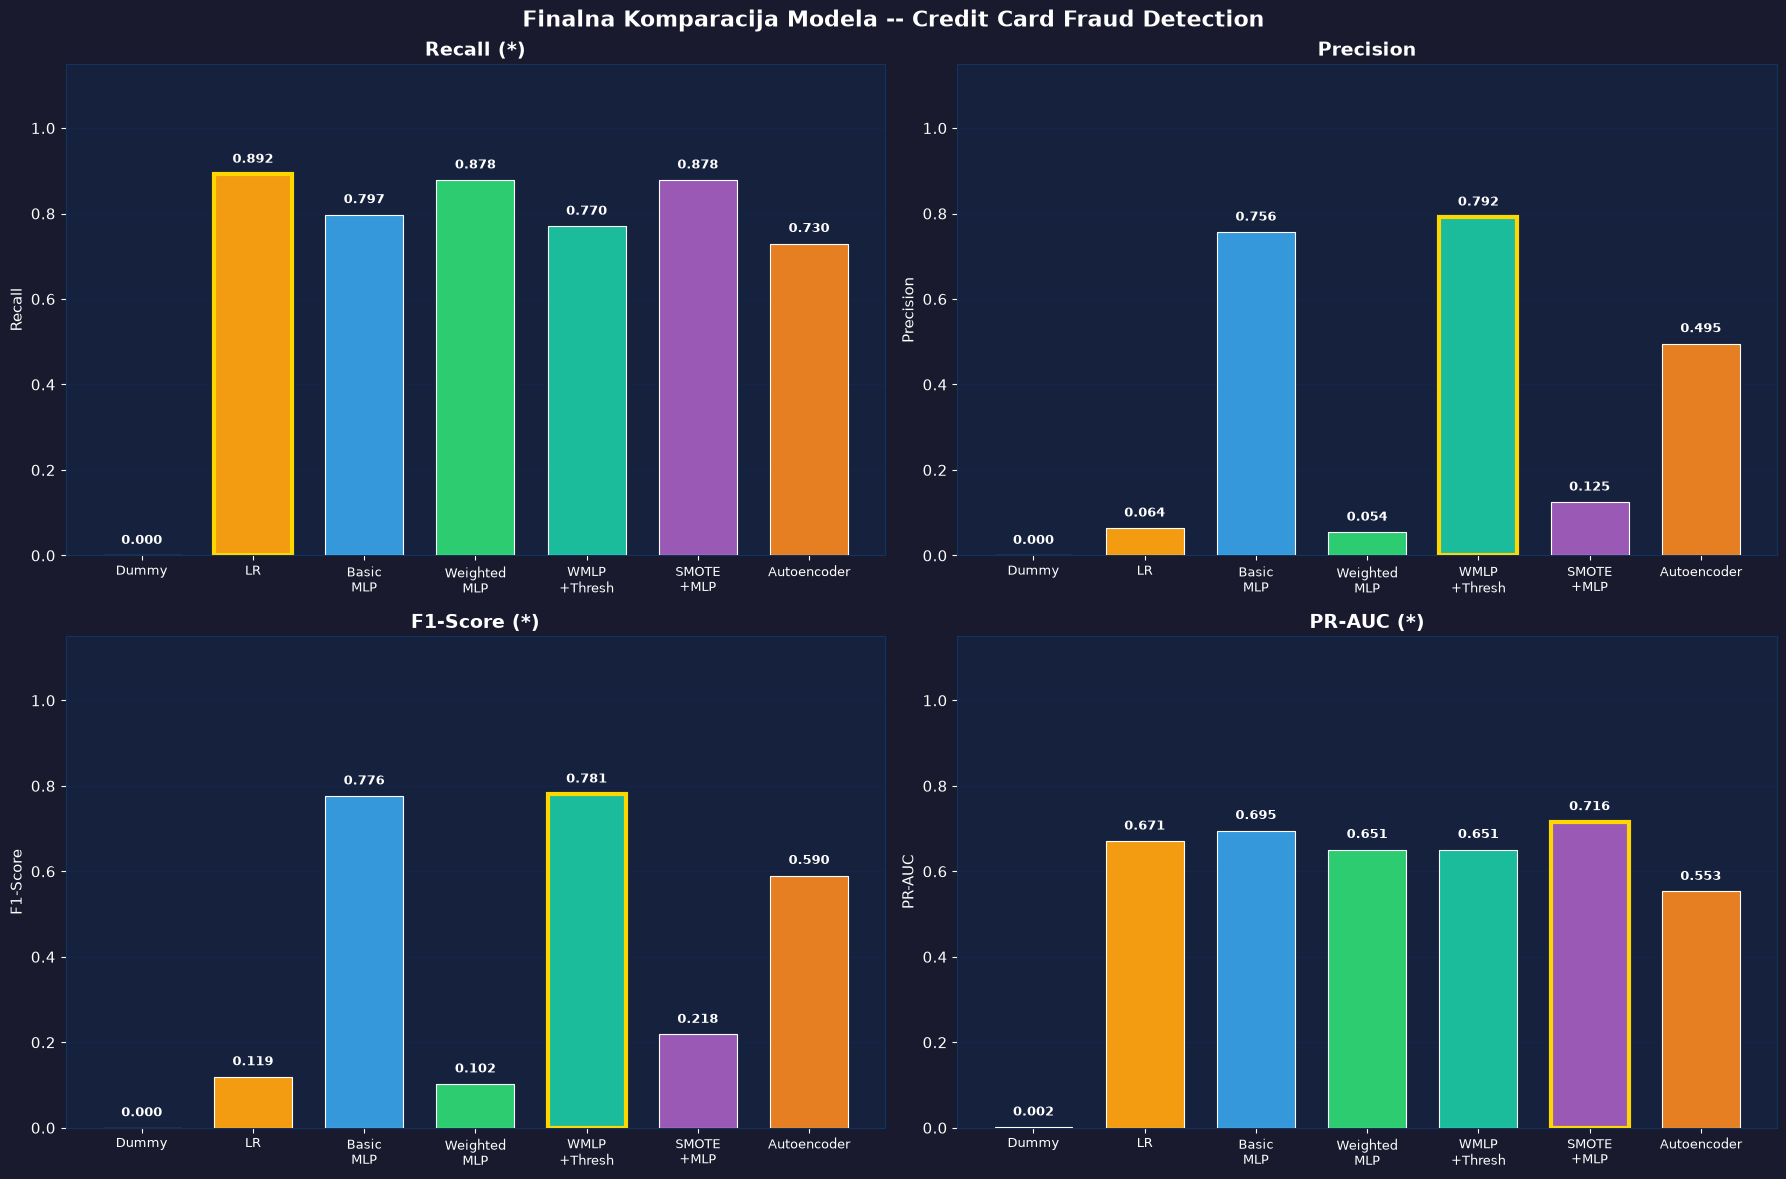

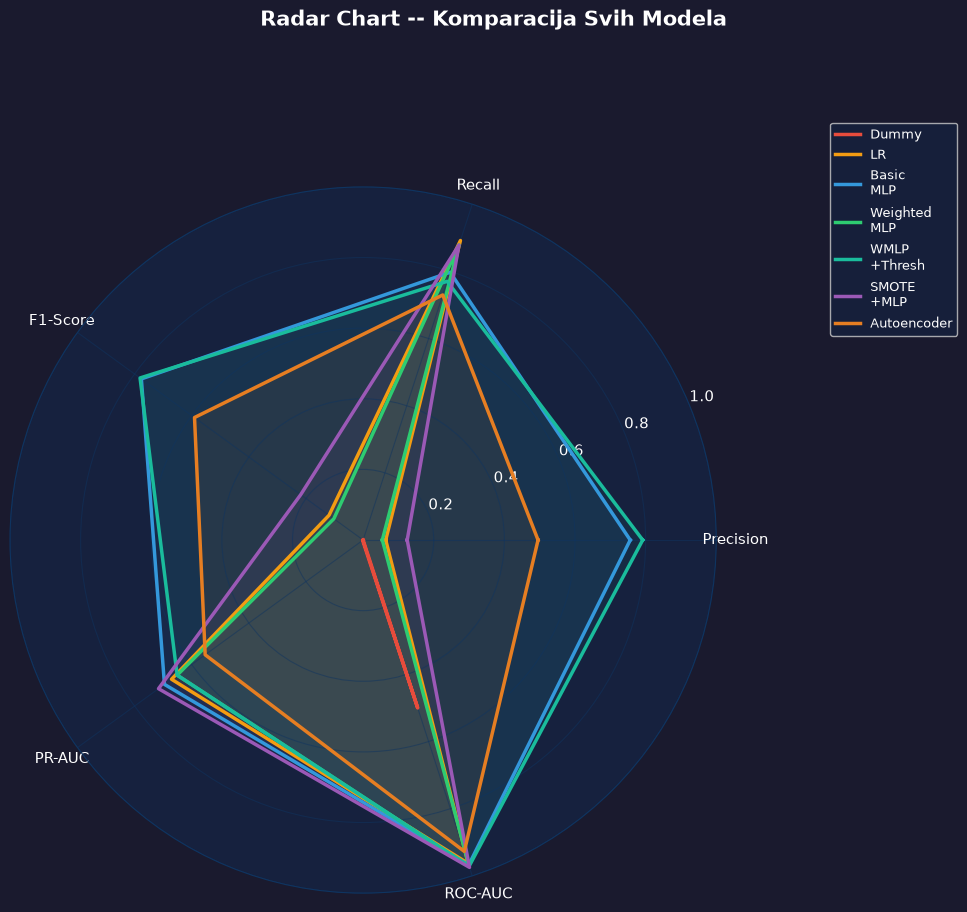

Sve vizualizacije sacuvane!


In [25]:
# ============================================================
# 13. FINALNA KOMPARACIJA SVIH MODELA
# ============================================================

results_df = pd.DataFrame(ALL_RESULTS).T
results_df = results_df[['Precision','Recall','F1-Score','PR-AUC','ROC-AUC','Threshold']]
results_df = results_df.round(4)

print('=' * 75)
print('  FINALNA KOMPARACIJA MODELA (na test skupu)')
print('=' * 75)
print(results_df.to_string())
print('=' * 75)

print('\nNajbolji rezultat po metrici:')
for metric in ['Recall', 'Precision', 'F1-Score', 'PR-AUC']:
    best_m = results_df[metric].idxmax()
    print(f'  {metric:12}: {best_m:40}  ->  {results_df.loc[best_m, metric]:.4f}')

# Bar chartovi za sve metrike
models   = list(results_df.index)
short_lbl = {
    'Dummy Baseline':           'Dummy',
    'Logistic Regression':      'LR',
    'Basic MLP':                'Basic\nMLP',
    'Weighted MLP':             'Weighted\nMLP',
    'Weighted MLP + Threshold': 'WMLP\n+Thresh',
    'SMOTE + MLP':              'SMOTE\n+MLP',
    'Autoencoder':              'Autoencoder'
}
xlabels = [short_lbl.get(m, m) for m in models]
x       = np.arange(len(models))
palcols = [FRAUD_COLOR,'#f39c12',PRIMARY_COLOR,LEGIT_COLOR,'#1abc9c',SECONDARY_COLOR,'#e67e22']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Finalna Komparacija Modela -- Credit Card Fraud Detection',
             fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, metric in enumerate(['Recall','Precision','F1-Score','PR-AUC']):
    ax   = axes[idx]
    vals = results_df[metric].values
    bars = ax.bar(x, vals, color=palcols, edgecolor='white', linewidth=0.8, width=0.7, zorder=3)
    bars[np.argmax(vals)].set_edgecolor('gold')
    bars[np.argmax(vals)].set_linewidth(3)
    star = ' (*)' if metric in ['Recall','F1-Score','PR-AUC'] else ''
    ax.set_title(f'{metric}{star}', fontsize=14, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(xlabels, fontsize=9)
    ax.set_ylabel(metric); ax.set_ylim(0, 1.15)
    ax.set_facecolor('#16213e'); ax.grid(axis='y', alpha=0.3, zorder=0)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('final_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()

# Radar Chart
radar_metrics = ['Precision','Recall','F1-Score','PR-AUC','ROC-AUC']
N      = len(radar_metrics)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
fig.suptitle('Radar Chart -- Komparacija Svih Modela', fontsize=15, fontweight='bold')

for i, (mname, row) in enumerate(results_df.iterrows()):
    vals  = [row[m] for m in radar_metrics] + [row[radar_metrics[0]]]
    color = palcols[i % len(palcols)]
    ax.plot(angles, vals, color=color, linewidth=2.5,
            label=short_lbl.get(mname, mname))
    ax.fill(angles, vals, color=color, alpha=0.07)

ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar_metrics, fontsize=11)
ax.set_ylim(0,1); ax.set_yticks([0.2,0.4,0.6,0.8,1.0])
ax.grid(alpha=0.5)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig('final_comparison_radar.png', dpi=150, bbox_inches='tight')
plt.show()

print('Sve vizualizacije su sacuvane.')


## 14. Zakljucak

### Sta sam naucila iz ovog rada

Najvazniji uvid iz celog ovog rada je da accuracy sama po sebi ne govori skoro nista
kod ovako nebalansiranog dataseta. Dummy model koji uvek predvidja "legitimno" ima
~99.83% accuracy, a ne pronalazi nijednu prevaru -- sto je bio i pocetni motiv da se
u nastavku rada oslanjam na Recall, Precision, F1 i PR-AUC, a ne na accuracy.

### Odgovori na pitanja koja sam sebi postavila tokom rada

**Zasto accuracy nije dovoljna?**
Kod ovako nebalansiranih klasa, model koji samo "pogadja" vecinsku klasu ima skoro
savrsenu accuracy, a u praksi je beskoristan. Zato su Recall, Precision i PR-AUC
mnogo relevantniji za ovaj problem.

**Kako class imbalance utice na treniranje?**
Videlo se direktno kod Basic MLP-a: gradijentni spust minimizira ukupan loss, a kako
je 99.83% primera legitimno, model najlakse dolazi do niskog loss-a tako sto skoro
uvek predvidja "legitimno" -- fraud primeri (samo 492 od 284,807) imaju premalen uticaj.

**Da li class weighting zaista pomaze?**
Da, i to prilicno vidljivo -- Weighted MLP je imao znatno bolji Recall od Basic MLP-a
uz istu arhitekturu, sto potvrdjuje da je razlog bio upravo u tretmanu nebalansiranosti,
a ne u samoj mrezi.

**Sta threshold tuning menja?**
Pomeranjem praga ispod 0.5 se podize Recall po cenu Precision-a. U ovom radu sam prag
birala tako da maksimizuje F1 na validacionom skupu, ali u stvarnom sistemu bi taj
izbor verovatno zavisio i od toga koliko banci/kompaniji kosta propustena prevara u
odnosu na lazni alarm -- to je vise poslovna nego tehnicka odluka.

**Kako se autoencoder poredi sa supervised pristupima?**
Rezultati u tabeli u prethodnoj celiji pokazuju konkretno poredjenje po PR-AUC.
Ono sto mi je zanimljivo je da autoencoder uopste ne vidi fraud primere tokom
treniranja, a opet uspeva da ih razlikuje na osnovu reconstruction error-a -- to je
korisno u scenariju gde labele uopste ne bi bile dostupne.

### Ogranicenja rada

Nekoliko stvari bih istakla kao ogranicenje: hiperparametri (broj slojeva,
learning rate, SMOTE odnos) nisu sistematski tunirani (npr. grid/random search), vec su
postavljeni na razumne, uobicajene vrednosti. Takodje, rezultati zavise od jednog train/val/test
splita (fiksiran SEED), pa bi se za ozbiljniju procenu moglo koristiti i cross-validation.

### Sta bi bilo zanimljivo probati dalje

- Focal Loss kao alternativu class weightingu
- Ensemble pristup (npr. kombinovanje Weighted MLP-a i Autoencoder-a)
- SHAP vrednosti, da se vidi koje karakteristike najvise uticu na pojedinacnu predikciju
- Eventualno LSTM/sekvencijalni model, ako bi se transakcije posmatrale hronoloski po korisniku

---

*Ovaj notebook je radjen kao projekat/seminarski rad za predmet Duboko ucenje i neuronske mreze.*